In [1]:
# Standard library
import argparse
import csv
import itertools
import os
import random
import sys
from collections import Counter

# Add project path
sys.path.insert(0, '/hkfs/work/workspace/scratch/cc7738-automorphism/ANP4Link')

# Third-party libraries
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from torch import Tensor
from scipy.sparse.linalg import eigsh
from scipy.stats import qmc

# PyTorch Geometric
from torch_geometric.datasets import Amazon, Planetoid
from torch_geometric.nn import WLConv
from torch_geometric.typing import Adj
from torch_geometric.utils import (
    degree,
    from_networkx,
    is_sparse,
    scatter,
    sort_edge_index,
    to_edge_index,
    to_undirected,
    train_test_split_edges,
)

# OGB
from ogb.linkproppred import PygLinkPropPredDataset

# Project-specific modules
from syn_graph.graph_generation import GraphType, generate_graph
from syn_graph.syn_random import RegularTilling, init_regular_tilling

from syn_real.custom_wl import WLConvOptimized
from syn_real.measure import hash_links_by_orbit
from syn_real.plotting import plot_orbit_dist, plot_orbit_histogram

/home/hk-project-test-p0021478/cc7738/anaconda3/envs/EAsF/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def run_wl_test_and_group_nodes(edge_index, num_nodes, num_iterations=1000):
    """
    Runs the Weisfeiler-Lehman (WL) test and groups nodes with similar hashed labels.
    
    Args:
        edge_index (Tensor): The edge index tensor (2, |E|) representing the graph.
        num_nodes (int): The number of nodes in the graph.
        num_iterations (int): Number of WL iterations.
    
    Returns:
        node_groups (dict): Mapping from WL hashes to node sets.
        node_labels (Tensor): Final hashed labels for each node.
    """
    # wl = WLConvMultiFeature()  
    wl = WLConvOptimized()  

    node_labels = np.ones(num_nodes)
    for _ in range(num_iterations):
        node_labels = wl(node_labels, edge_index)  
    # Group nodes based on final hashed values
    node_groups = {}
    for node, label in enumerate(node_labels.tolist()):
        if label not in node_groups:
            node_groups[label] = []
        node_groups[label].append(node)
    _, new_labels = torch.unique(node_labels, return_inverse=True)
    return node_groups, node_labels, new_labels

In [3]:
def plot_graph_with_orbits(G, pos, orbits, custom_labels=None, figsize=(8, 6), cmap='tab20b'):
    """
    Plots a NetworkX graph with node coloring based on orbit labels.
    
    Parameters:
        G (nx.Graph): The graph to plot.
        pos (dict): Node positions.
        orbits (list or array): Orbit label for each node.
        custom_labels (dict, optional): Dictionary of node labels.
        figsize (tuple): Figure size for the plot.
        cmap (str): Matplotlib colormap for nodes.
    """
    plt.figure(figsize=figsize)
    node_colors = [orbits[node] for node in G.nodes()]
    nx.draw(
        G,
        pos=pos,
        labels=custom_labels,
        node_color=node_colors,
        cmap=cmap,
        node_size=500,
        font_weight='bold',
        edgecolors='black'
    )
    plt.title("Graph Colored by Orbit Labels")
    # plt.savefig('graph_with_orbits.png', bbox_inches='tight')
    plt.show()
    plt.close()

In [4]:
def plot_orbit_histogram(orbits, figsize=(6, 4)):
    """
    Plots a histogram of orbit label frequencies.
    
    Parameters:
        orbits (list or array): Orbit labels.
        figsize (tuple): Figure size for the plot.
    """
    plt.figure(figsize=figsize)
    plt.hist(orbits,
             bins=range(min(orbits), max(orbits) + 2),
             align='left',
             rwidth=0.8)
    plt.xlabel('Orbit Label')
    plt.ylabel('Frequency')
    plt.title('Histogram of Orbit Labels')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()
    plt.close()

In [5]:
def compute_automorphism_metrics(node_groups, num_nodes):
    """
    Computes numerical metrics for graph automorphism based on WL node grouping.
    Args:
        node_groups (dict): Dictionary mapping WL hash values to lists of node indices.
        num_nodes (int): Total number of nodes in the graph.

    Returns:
        dict: Automorphism metrics {A_r1, C_auto, H_auto}
    """
    # Compute the size of each group (how many nodes share the same WL label)

    group_sizes = np.array([len(group) for group in node_groups.values()])
    
    A_r1 = np.sum(group_sizes**2) / num_nodes**2
    C_auto = len(node_groups)
    A_r_norm_1 = 1 + np.log(A_r1) / np.log(num_nodes) # lower is less automorphism
    A_r_norm_2 = np.log(np.sum(group_sizes**2)) / (2 * np.log(num_nodes)) 
    A_r_log = (np.log(np.sum(group_sizes**2)) - np.log(num_nodes**2)) / np.log(num_nodes)
    automorphism_score = (len(node_groups) / num_nodes)
    return {
        "Automorphism Ratio (A_r1)": A_r1,
        "A_r_norm_2": A_r_norm_2,
        "A_r_norm_1": A_r_norm_1,
        "Number of Unique Groups (C_auto)": C_auto,
        "Automorphism Ratio (A_r_log)": A_r_log,
        "num_nodes": num_nodes,
        "automorphism_score": automorphism_score
    }, num_nodes, group_sizes

In [6]:
def count_automorphic_edges(G, node_groups:list):
    """
    Counts intra-orbit and inter-orbit edges in a graph G based on node_groups,
    excluding nodes that are the only ones in their group.

    Parameters:
        G (networkx.Graph): The input graph.
        node_groups (list): A list where the index is the node ID and the value is the orbit/group ID.

    Returns:
        tuple: (intra_orbit_edges, inter_orbit_edges)
    """
    node_groups = node_groups.tolist() if isinstance(node_groups, Tensor) else node_groups
    group_counts = Counter(node_groups)
    
    unique_nodes = set()
    for i, group in enumerate(node_groups):
        if group_counts[group] == 1:
            unique_nodes.add(i)

    valid_nodes = set()
    for i, group in enumerate(node_groups):
        if group_counts[group] > 1:
            valid_nodes.add(i)

    valid_nodes = list(valid_nodes)
    intra_orbit_edges = 0
    inter_orbit_edges = 0
    for u, v in G.edges():
        # if u in unique_nodes and v in unique_nodes:
        #     continue 
        # print(f"u: {u}, v: {v}, group_u: {node_groups[u]}, group_v: {node_groups[v]}")
        if node_groups[u] == node_groups[v]:
            intra_orbit_edges += 1
        else:
            inter_orbit_edges += 1
    print(f"Intra-orbit edges: {intra_orbit_edges}, Inter-orbit edges: {inter_orbit_edges}")
    print(f"Non-distinguishable edges: {(intra_orbit_edges+inter_orbit_edges)}")
    return intra_orbit_edges, inter_orbit_edges

In [7]:
# random split dataset
def randomsplit(dataset, val_ratio: float=0.10, test_ratio: float=0.2):
    def removerepeated(ei):
        ei = to_undirected(ei)
        ei = ei[:, ei[0]<ei[1]]
        return ei
    data = dataset[0]
    data.num_nodes = data.x.shape[0]
    data = train_test_split_edges(data, test_ratio, test_ratio)
    split_edge = {'train': {}, 'valid': {}, 'test': {}}
    num_val = int(data.val_pos_edge_index.shape[1] * val_ratio/test_ratio)
    data.val_pos_edge_index = data.val_pos_edge_index[:, torch.randperm(data.val_pos_edge_index.shape[1])]
    split_edge['train']['edge'] = removerepeated(torch.cat((data.train_pos_edge_index, data.val_pos_edge_index[:, :-num_val]), dim=-1)).t()
    split_edge['valid']['edge'] = removerepeated(data.val_pos_edge_index[:, -num_val:]).t()
    split_edge['valid']['edge_neg'] = removerepeated(data.val_neg_edge_index).t()
    split_edge['test']['edge'] = removerepeated(data.test_pos_edge_index).t()
    split_edge['test']['edge_neg'] = removerepeated(data.test_neg_edge_index).t()
    return split_edge

In [8]:
import matplotlib.pyplot as plt

def plot_degree_distribution_stem(G):
    """
    Plots the degree distribution of a graph G as a stem plot.

    Parameters:
    - G: A NetworkX graph object.
    """
    degrees = [d for _, d in G.degree()]
    degrees = sorted(degrees, reverse=True)

    plt.figure()
    markerline, stemlines, _ = plt.stem(
        degrees,
        markerfmt='bo',
        basefmt=' '
    )
    markerline.set_markerfacecolor('none')
    stemlines.set_linewidth(0.5)

    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [9]:
def dataloader(args):
    if args.data_name in ['ogbl-ddi', 'ogbl-collab', 'ogbl-ppa', 'ogbl-citation2']:
        dataset = PygLinkPropPredDataset(name=args.data_name, 
                                         root=os.path.abspath(os.path.join(get_root_dir(), f"dataset")))
        print(f"Dataset: {args.data_name}")
        print(f"Number of graphs: {len(dataset)}")

        data = dataset[0]
        print("data", data)
        edge_index = data.edge_index
        num_nodes = data.num_nodes
        G = data
        
    if args.data_name in ["Cora", "Citeseer", "Pubmed"]:
        dataset = Planetoid(root="dataset", name=args.data_name)
        data = dataset[0]
        edge_index = data.edge_index
        data.num_nodes = data.x.shape[0]
        num_nodes = data.num_nodes
        G = data

    if args.data_name in ["Computers", "Photo"]:
        dataset = Amazon(root="dataset", name=args.data_name)
        split_edge = randomsplit(dataset)
        data = dataset[0]
        data.edge_index = to_undirected(split_edge["train"]["edge"].t())
        edge_index = data.edge_index
        num_nodes = data.x.shape[0]
        G = data 
        
    elif args.data_name in ['RegularTilling.SQUARE_GRID', 
                          'RegularTilling.HEXAGONAL', 
                          'RegularTilling.TRIANGULAR', 
                          'RegularTilling.KAGOME_LATTICE']:
        N = 100
        G, _, _, pos = init_regular_tilling(N, eval(args.data_name), seed=None)
        data = from_networkx(G)
        num_nodes = G.number_of_nodes()
        edge_index = data.edge_index
        print(f"Dataset: {args.data_name}")
        print("data", data)
        
        
    elif args.data_name in ['GraphType.TREE', 
                            'GraphType.BARABASI_ALBERT',
                            'GraphType.ERDOS_RENYI']:    
        N = 100
        G = generate_graph(10, eval(args.data_name), seed=0)
        data = from_networkx(G)
        num_nodes = G.number_of_nodes()
        print(f"Dataset: {args.data_name}")
        print("data", data)
        
    return G, num_nodes, edge_index

In [10]:
def process_random_regular_graph():

    for degree in [10]:
        N = 4000 
        seed = random.randint(1, 100)
        from networkx import random_regular_graph
        G = random_regular_graph(degree, N, seed)
        # Visualize the graph
        pos = nx.spring_layout(G, seed=42)
        nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color='gray', node_size=500)
        plt.title(f"Random Regular Graph (n={N}, d={degree})")
        plt.savefig('random_graph.png')

        data = from_networkx(G)
        edge_index = data.edge_index
        node_groups, _ = run_wl_test_and_group_nodes(edge_index, num_nodes=G.number_of_nodes(), num_iterations=100)
        metrics, _, _ = compute_automorphism_metrics(node_groups, G.number_of_nodes())
        
        metrics.update({'data_name': 'random_regular'+'_'})
        print(metrics)
        csv_path = 'summary.csv'
        file_exists = os.path.isfile(csv_path)
        pd.DataFrame([metrics]).to_csv(csv_path, mode='a', index=False, header=not file_exists)

        print(degree)

In [11]:
def process_ERDOS_RENYI():

    for degree in [2, 4, 6, 8, 10, 20]:
        N = 2000 
        seed = random.randint(1, 100)
        G = nx.fast_gnp_random_graph(N, degree, seed, directed=False)

        pos = nx.spring_layout(G, seed=42)
        nx.draw(G, pos, with_labels=True, node_color='skyblue', edge_color='gray', node_size=500)
        plt.title(f"Random Regular Graph (n={N}, d={degree})")
        plt.show()

        data = from_networkx(G)
        edge_index = data.edge_index
        node_groups, node_labels = run_wl_test_and_group_nodes(edge_index, num_nodes=G.number_of_nodes(), num_iterations=100)
        metrics, num_nodes, group_sizes = compute_automorphism_metrics(node_groups, G.number_of_nodes())
        
        metrics.update({'data_name': 'random_gnp'+'_'})
        print(metrics)
        csv_path = 'summary.csv'
        file_exists = os.path.isfile(csv_path)
        pd.DataFrame([metrics]).to_csv(csv_path, mode='a', index=False, header=not file_exists)
        
        print(degree)

In [12]:
def save_metrics(metrics, graph_type, csv_path='summary.csv'):
    metrics['data_name'] = str(graph_type)
    df = pd.DataFrame([metrics])
    header = not os.path.isfile(csv_path)
    df.to_csv(csv_path, mode='a', index=False, header=header)
    print("Saved to summary.csv")

In [13]:
def count_orbit_edges(G, node_groups):
    # Create a mapping: node -> orbit_id

    intra_orbit_edges = 0
    inter_orbit_edges = 0

    try:
        for u, v in G.edges():
            if node_groups[u] == node_groups[v]:
                intra_orbit_edges += 1
            else:
                inter_orbit_edges += 1
    except:
    
        for links in G.edges():
            for u, v in links:
                if node_groups[u] == node_groups[v]:
                    intra_orbit_edges += 1
                else:
                    inter_orbit_edges += 1
    # print(f"Intra-orbit edges: {intra_orbit_edges}, Inter-orbit edges: {inter_orbit_edges}")
    print(f"{inter_orbit_edges/ (intra_orbit_edges + inter_orbit_edges) * 100}, of edges are inter-orbit")
    return intra_orbit_edges, inter_orbit_edges



In [14]:
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter


def create_orbit_labels(G, orbits):
    """
    Generate a mapping from each node in G to its orbit label.
    """
    if type(orbits) is torch.Tensor:
        orbits = orbits.tolist()
    return {node: str(orbits[idx]) for idx, node in enumerate(G.nodes())}


def plot_colored_graph(G, pos, labels, orbits, ax):
    """
    Plot the graph G colored by orbit labels on the given axis.
    """
    node_colors = [orbits[node] for node in G.nodes()]
    nx.draw(
        G,
        pos=pos,
        labels=labels,
        node_color=node_colors,
        cmap='tab20b',
        node_size=500,
        font_weight='bold',
        edgecolors='black',
        ax=ax
    )
    ax.set_title("Graph Colored by Orbit Labels")


def plot_degree_distribution(G, ax):
    """
    Plot the degree distribution of G as a stem plot.
    """
    degrees = sorted((d for _, d in G.degree()), reverse=True)
    markerline, stemlines, _ = ax.stem(degrees, markerfmt='bo', basefmt=' ')
    markerline.set_markerfacecolor('none')
    stemlines.set_linewidth(0.5)
    ax.set_xlabel("Degree")
    ax.set_ylabel("Frequency")
    ax.set_title("Degree Distribution")


def plot_orbit_histogram(orbits, ax):
    """
    Plot a sorted histogram of orbit sizes.
    """
    counts = Counter(orbits.tolist())
    sizes = sorted(counts.values(), reverse=True)
    markerline, stemlines, _ = ax.stem(sizes, markerfmt='bo', basefmt=' ')
    markerline.set_markerfacecolor('none')
    stemlines.set_linewidth(0.5)
    ax.set_xlabel("Orbit Index")
    ax.set_ylabel("Orbit Size")
    ax.set_title("Sorted Orbit Size")
    ax.grid(axis='y', linestyle='--', alpha=0.7)


def plot_edge_distribution(G, orbits, ax):
    """
    Plot the automorphic edge class distribution as a stem plot.
    """
    _, edge_class_counts = hash_links_by_orbit(G, orbits)
    markerline, stemlines, _ = ax.stem(edge_class_counts, markerfmt='bo', basefmt=' ')
    markerline.set_markerfacecolor('none')
    stemlines.set_linewidth(0.5)
    ax.set_title('Automorphic Edge Distribution')
    ax.set_xlabel("Automorphism Edge Classes")
    ax.set_ylabel("Frequency")


def plot_orbit_analysis(G, pos, orbits, figsize=(18, 6)):
    """
    Create a 1x4 subplot figure showing:
      1) Graph colored by orbits
      2) Degree distribution
      3) Sorted orbit size histogram
      4) Automorphic edge distribution

    Parameters:
    - G: networkx.Graph
    - pos: dict mapping nodes to positions
    - orbits: array-like of orbit labels aligned with G.nodes()
    - figsize: tuple for figure size
    """
    labels = create_orbit_labels(G, orbits)
    fig, axes = plt.subplots(1, 4, figsize=figsize)

    plot_colored_graph(G, pos, labels, orbits, axes[0])
    plot_degree_distribution(G, axes[1])
    plot_orbit_histogram(orbits, axes[2])
    plot_edge_distribution(G, orbits, axes[3])

    plt.tight_layout()
    plt.show()

In [15]:
def process_graph(N, graph_type, pos=None, is_grid=False, label="graph"):
    if graph_type == RegularTilling.SQUARE_GRID:
        G, _, _, pos = init_regular_tilling(N, RegularTilling.SQUARE_GRID, seed=None)
    elif graph_type == RegularTilling.TRIANGULAR:
        G, _, _, pos = init_regular_tilling(N, RegularTilling.TRIANGULAR, seed=None)
    elif graph_type == 'GraphType.COMPLETE':
        graph_type = 'GraphType.COMPLETE'
        G = nx.complete_graph(N)
    else:
        G = generate_graph(N, graph_type, seed=0)
    
    
    # Process Graph with WL Test
    data = from_networkx(G)
    edge_index = data.edge_index
    node_groups, node_labels, orbits = run_wl_test_and_group_nodes(edge_index, num_nodes=G.number_of_nodes(), num_iterations=100)
    
    custom_labels = {}
    for i, ov in zip(G.nodes(), orbits):
            custom_labels[i] = f"{ov}"

    # 4a. Quick-and-dirty: all four plots at once
    plot_orbit_analysis(G, pos, orbits)

    # save_metrics(metrics, f"{graph_type}_{N}", csv_path='summary.csv')

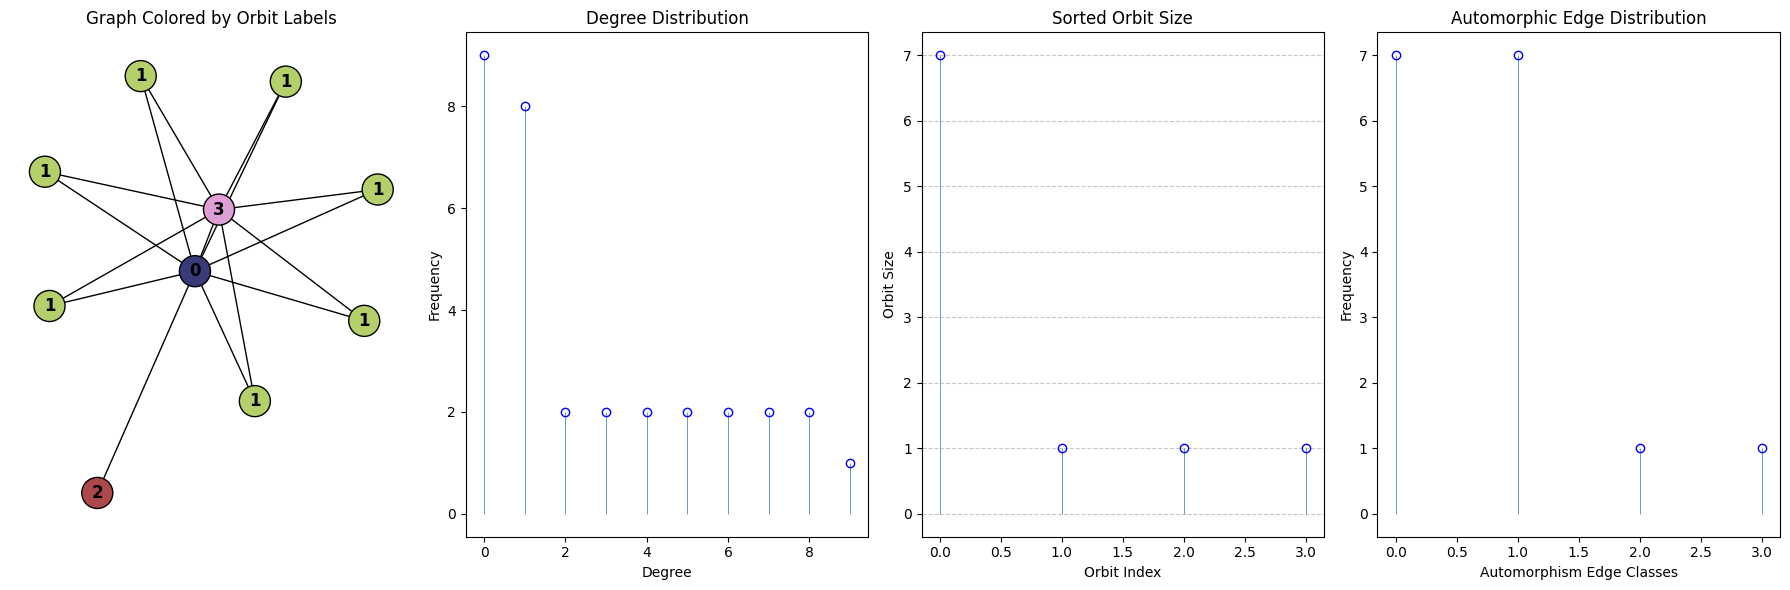

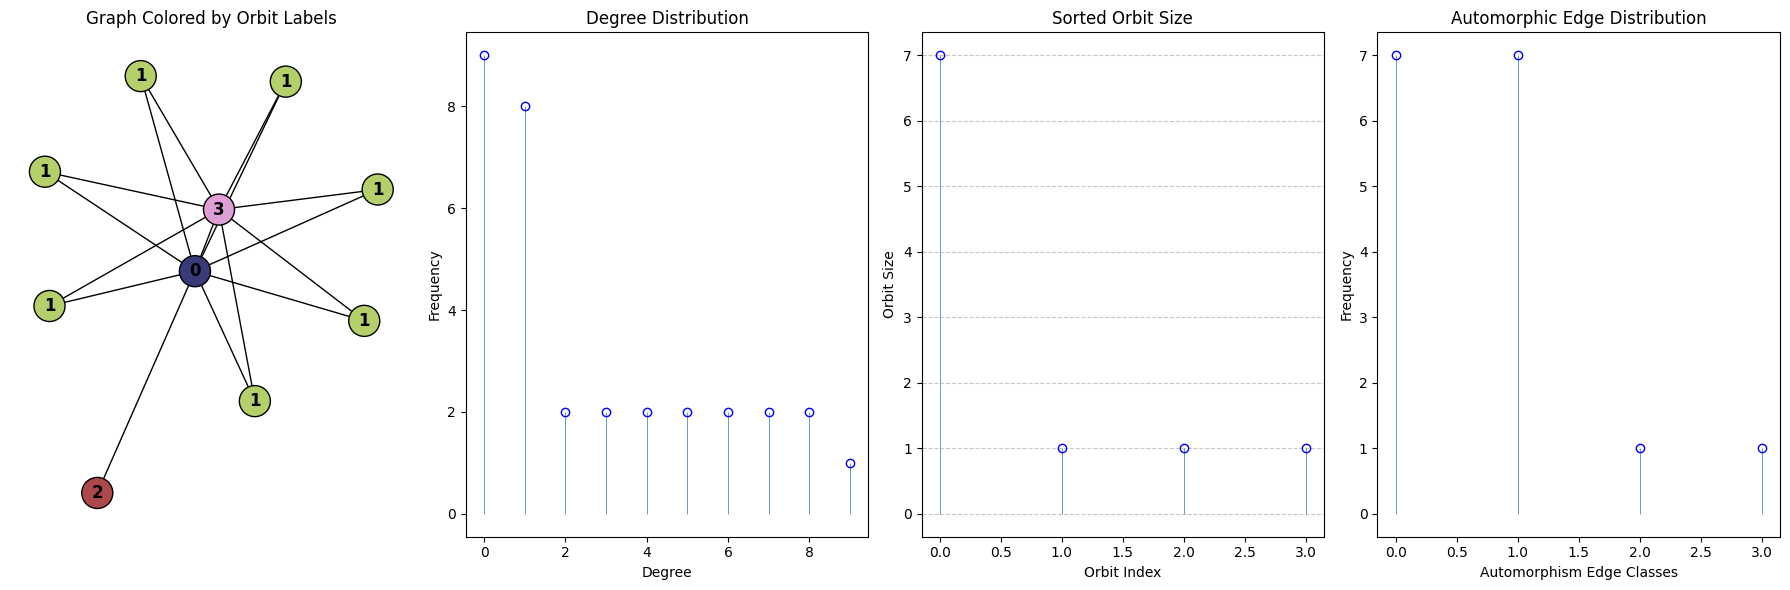

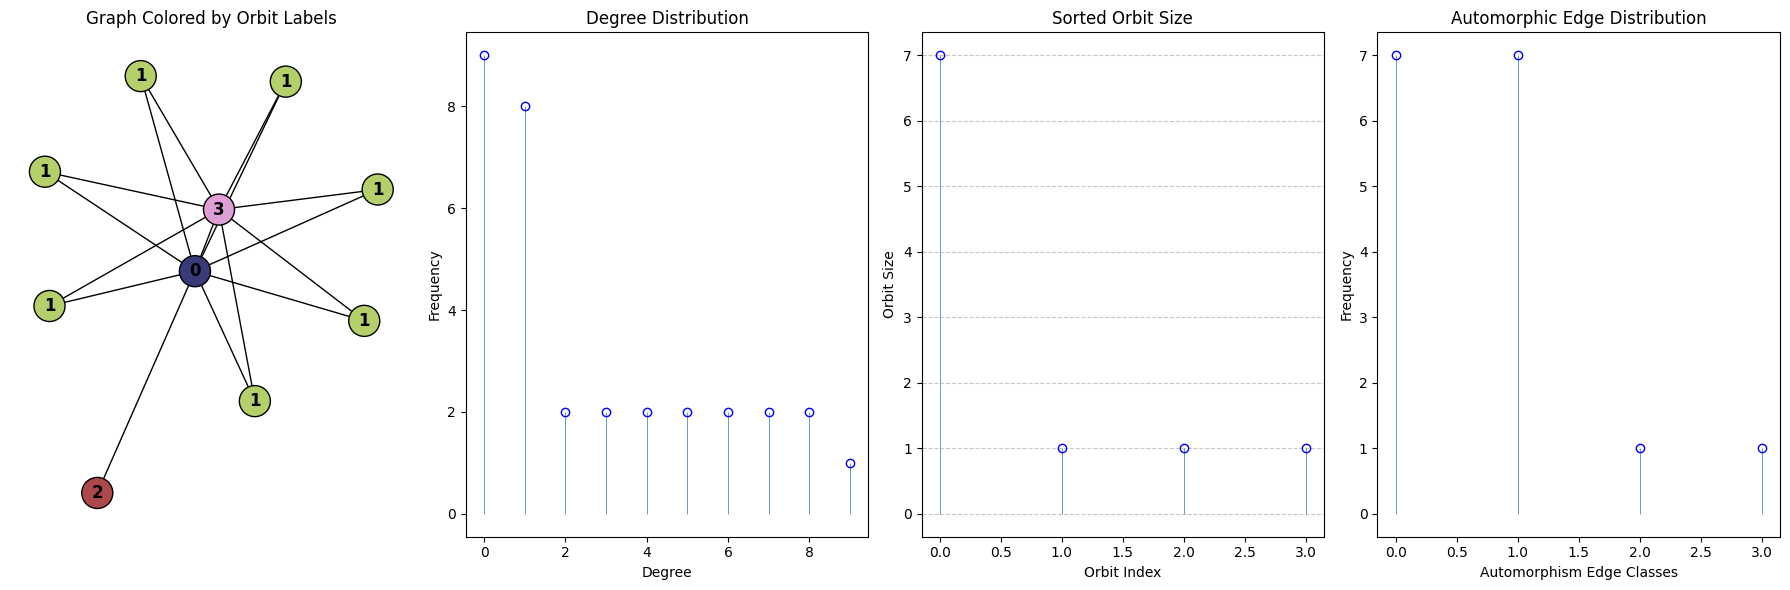

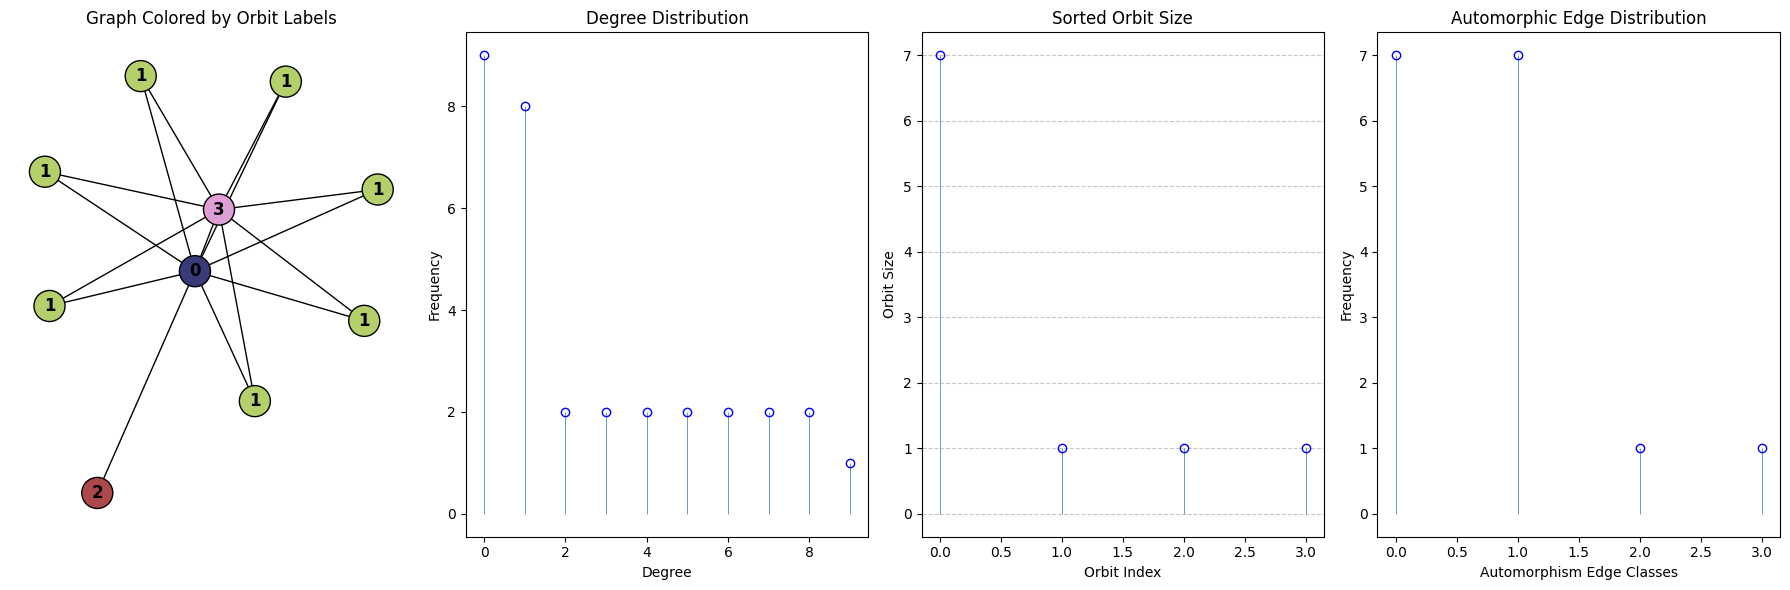

In [16]:
for N in range(4, 40, 10):
    process_graph(10, GraphType.BARABASI_ALBERT)

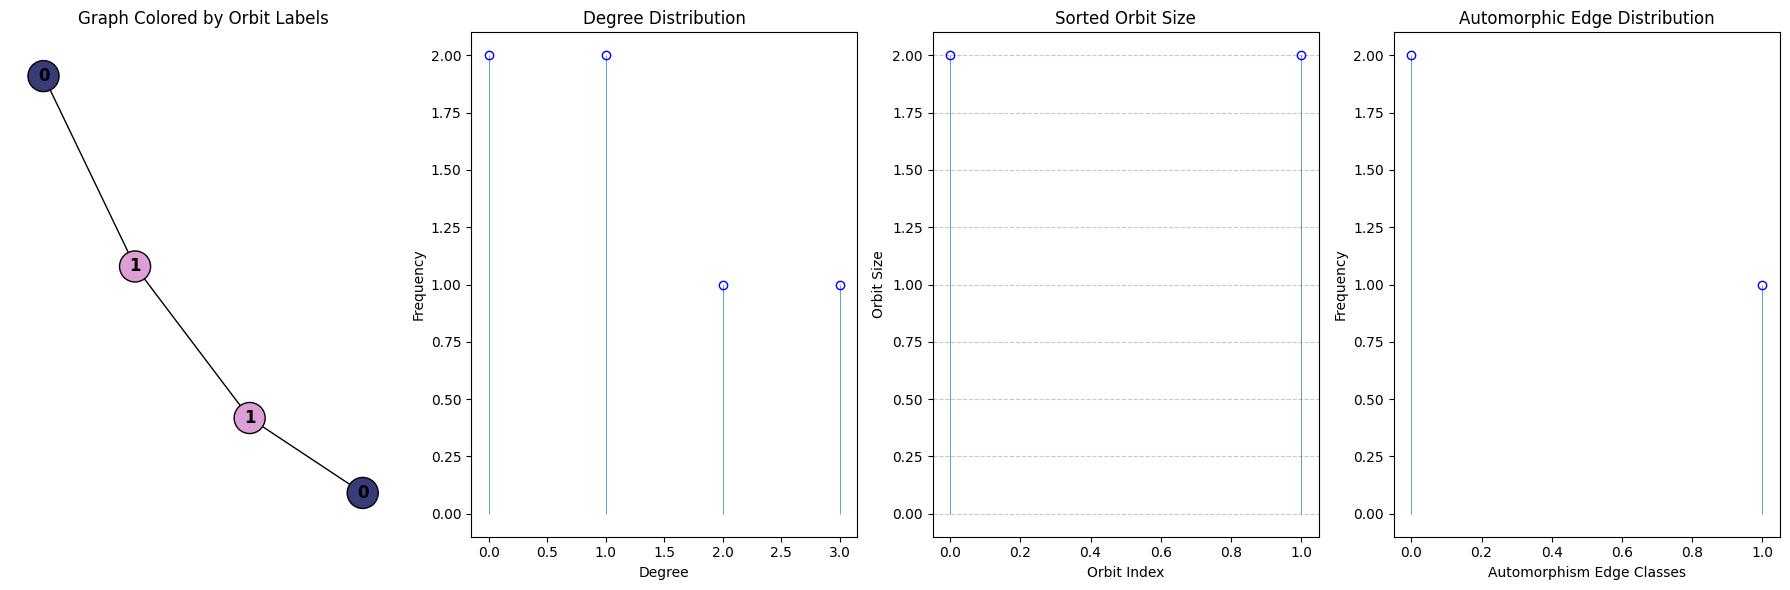

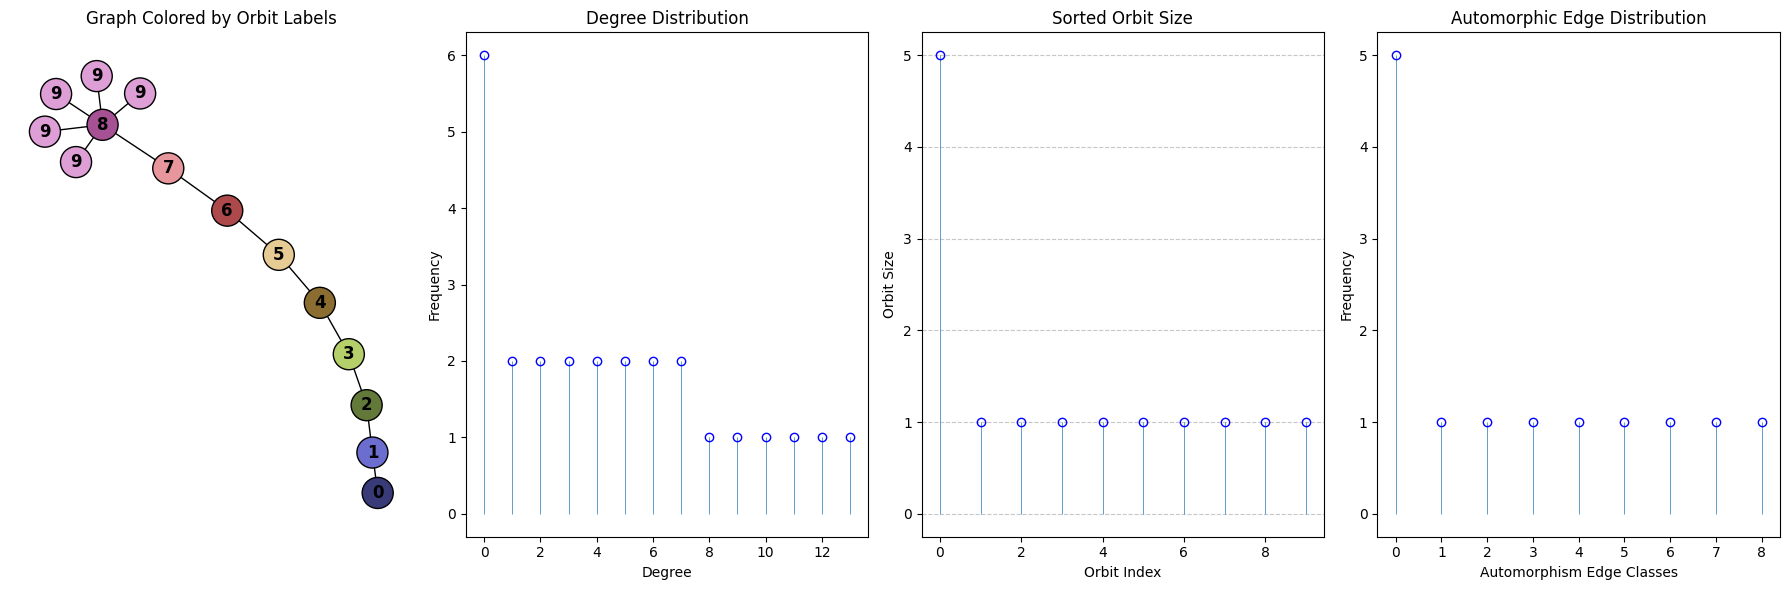

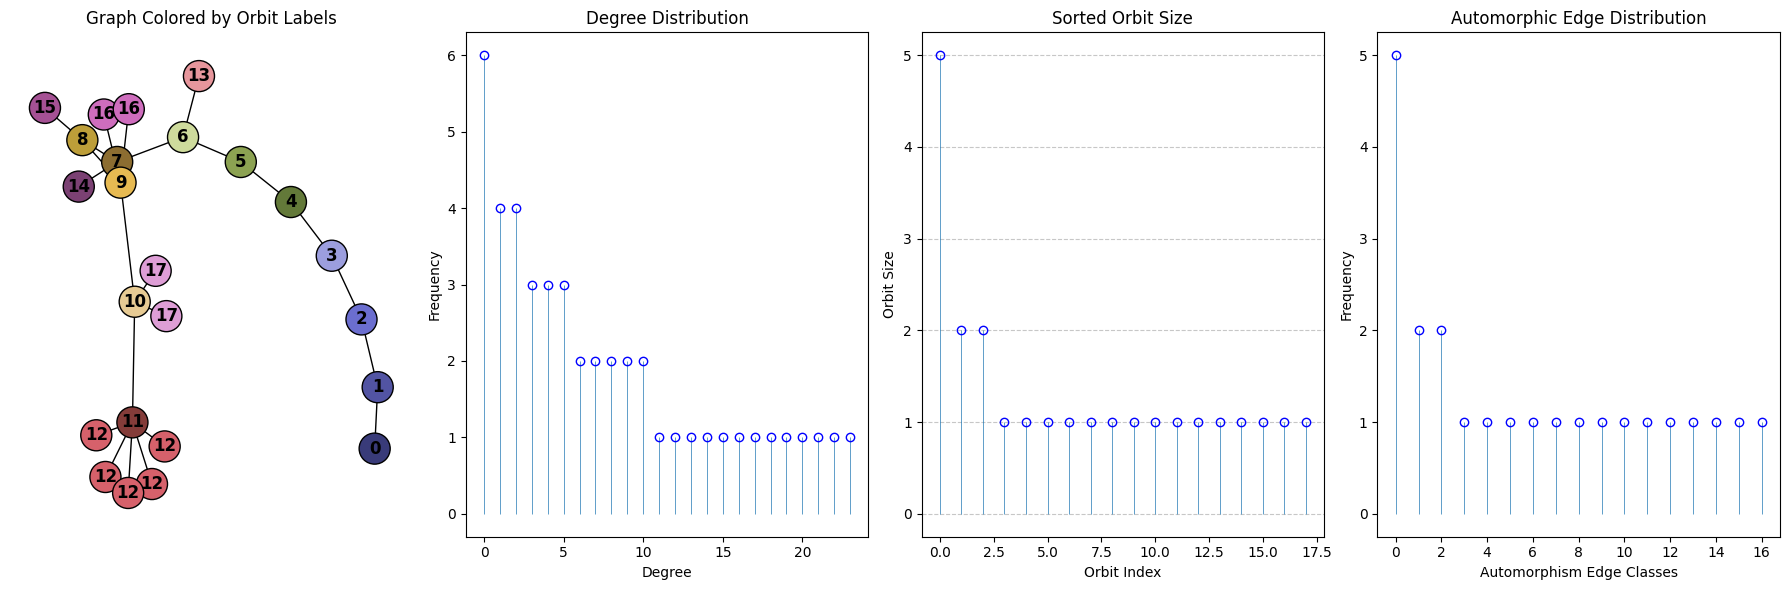

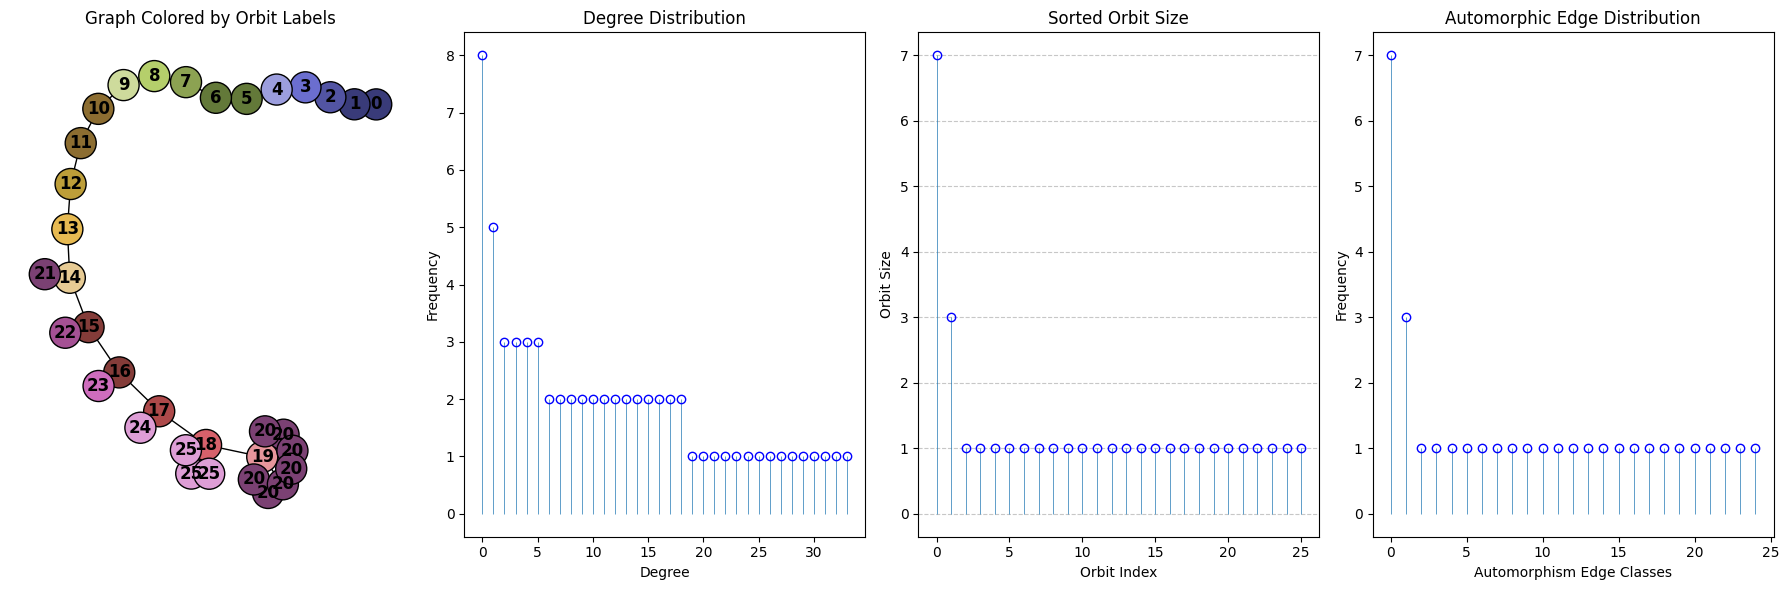

In [17]:
for N in range(4, 40, 10):
    process_graph(N, GraphType.TREE)

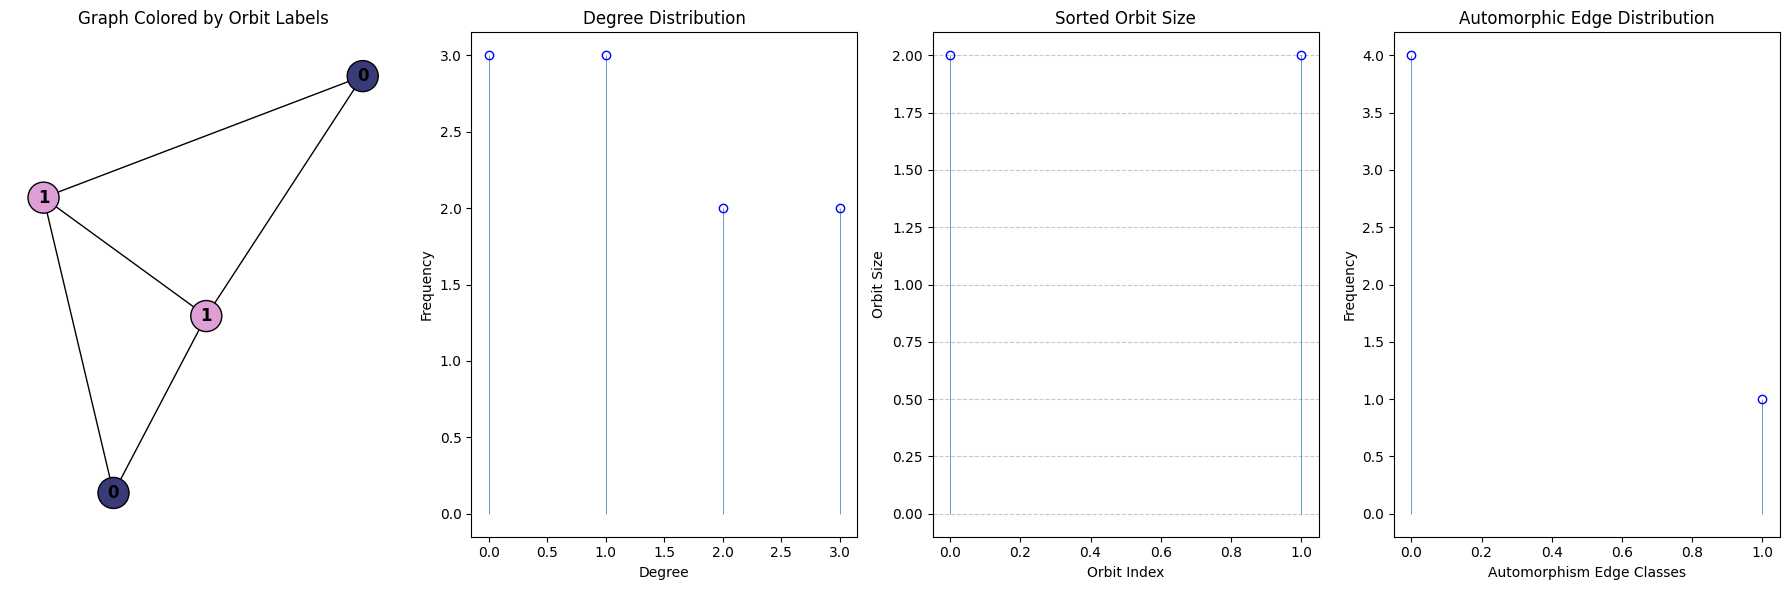

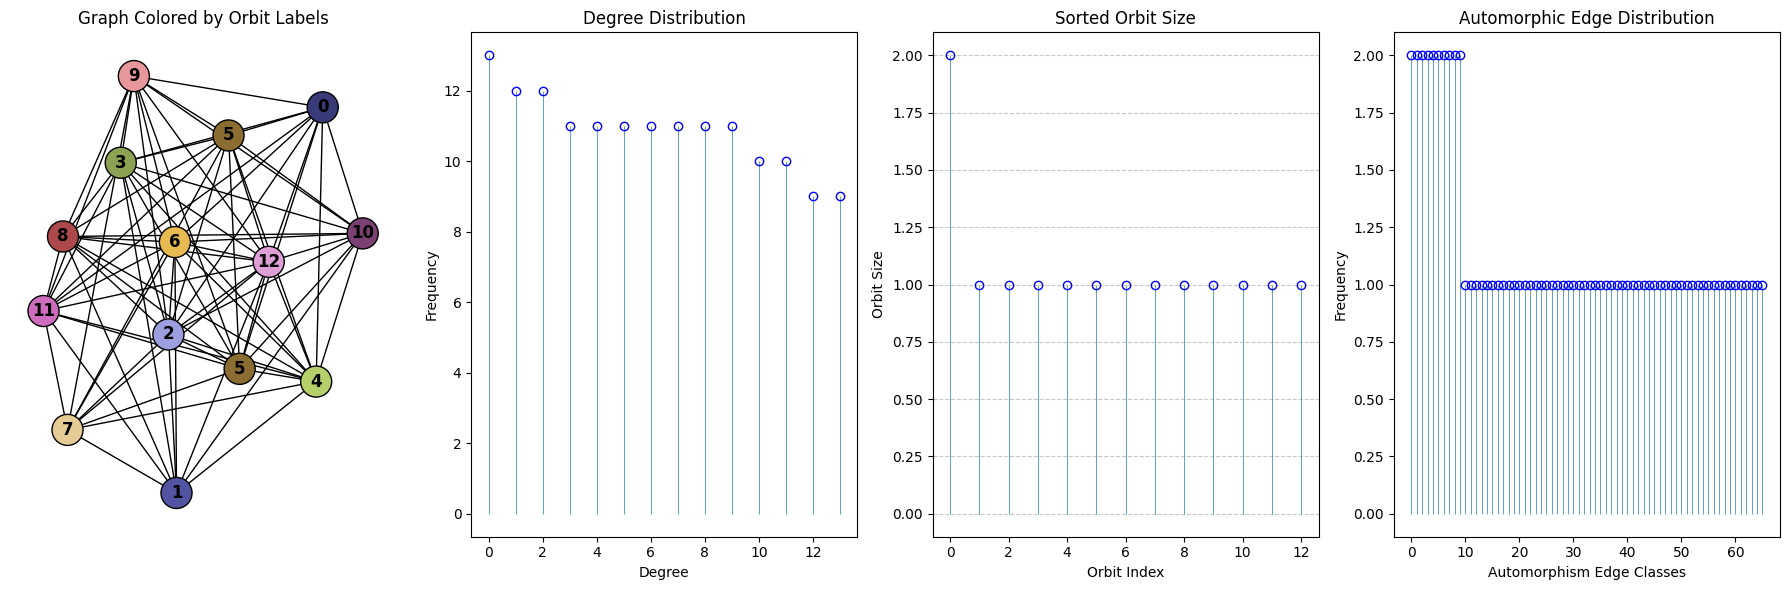

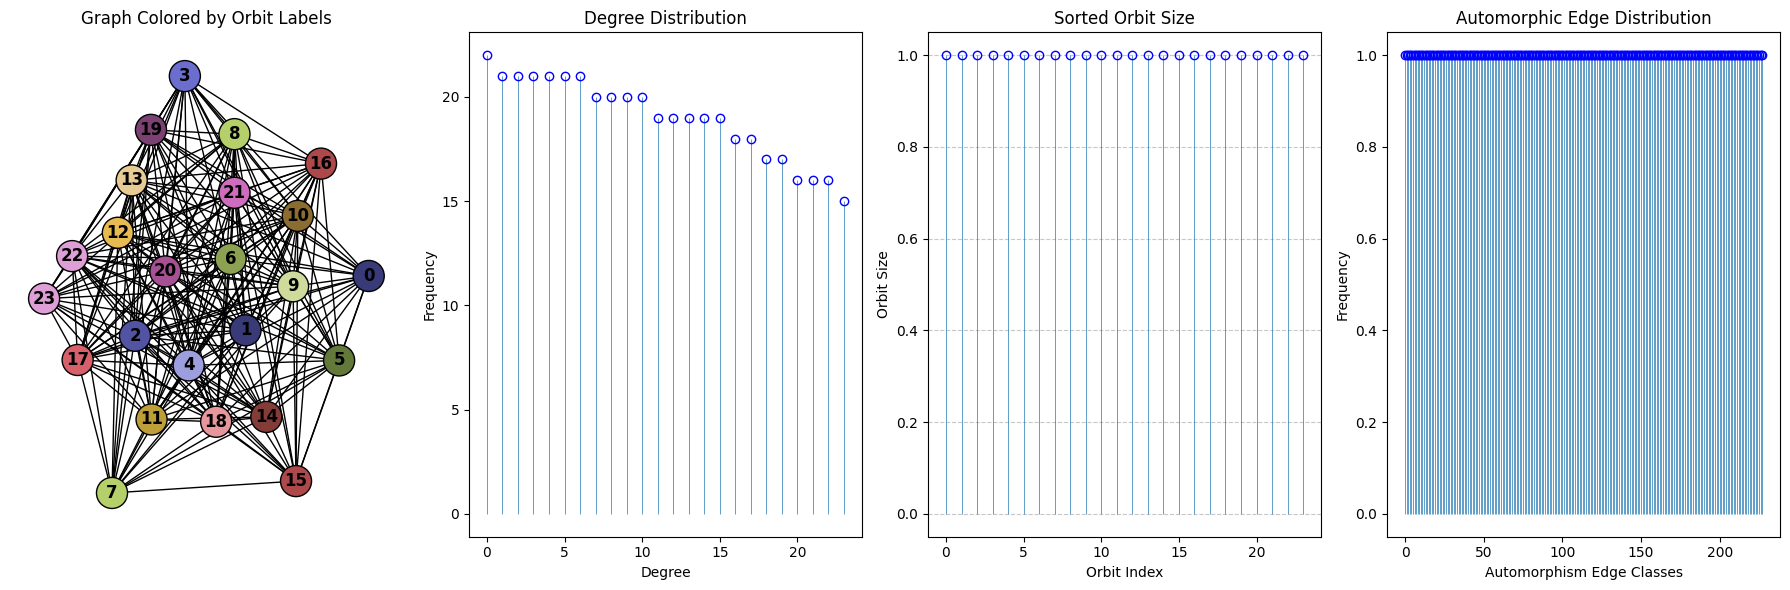

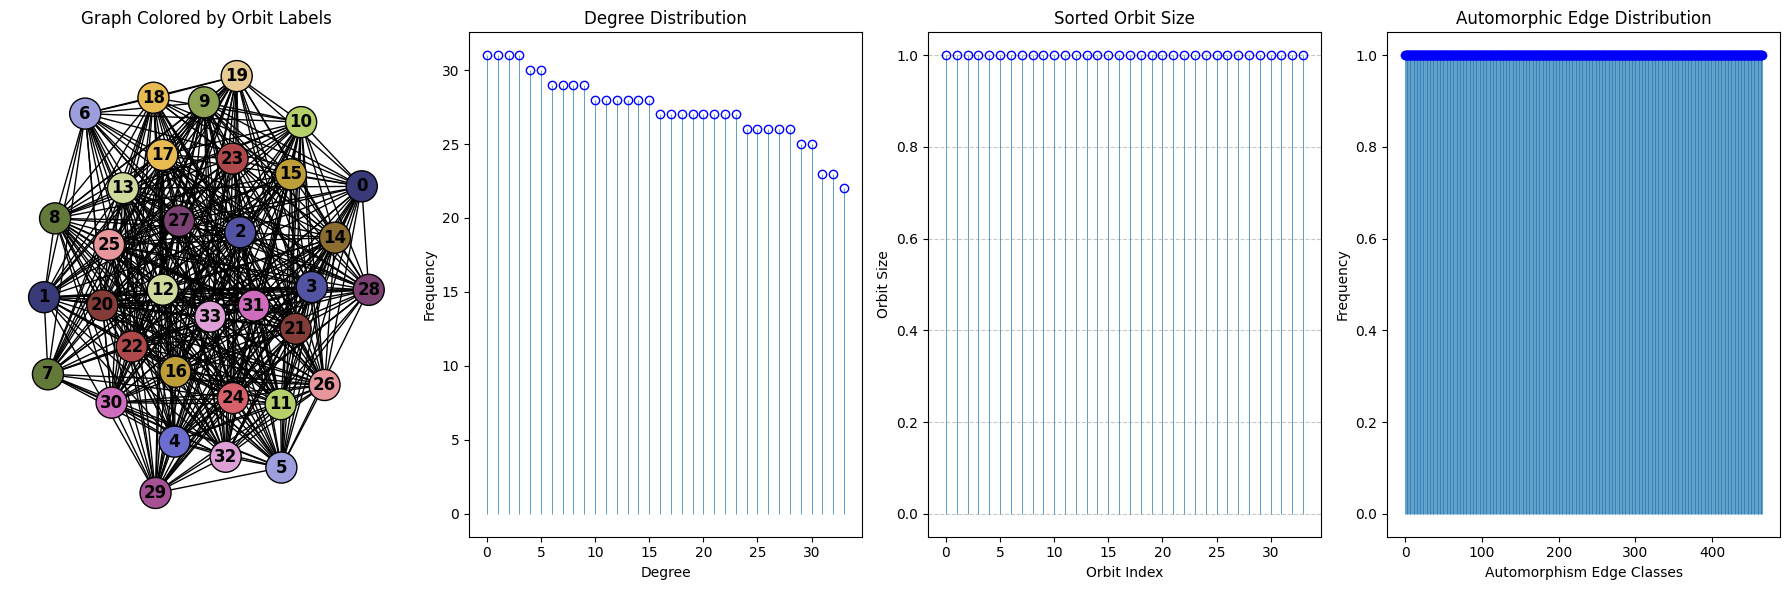

In [18]:
for N in range(4, 40, 10):
    process_graph(N, GraphType.ERDOS_RENYI)

Random type chosen:  GraphType.TREE


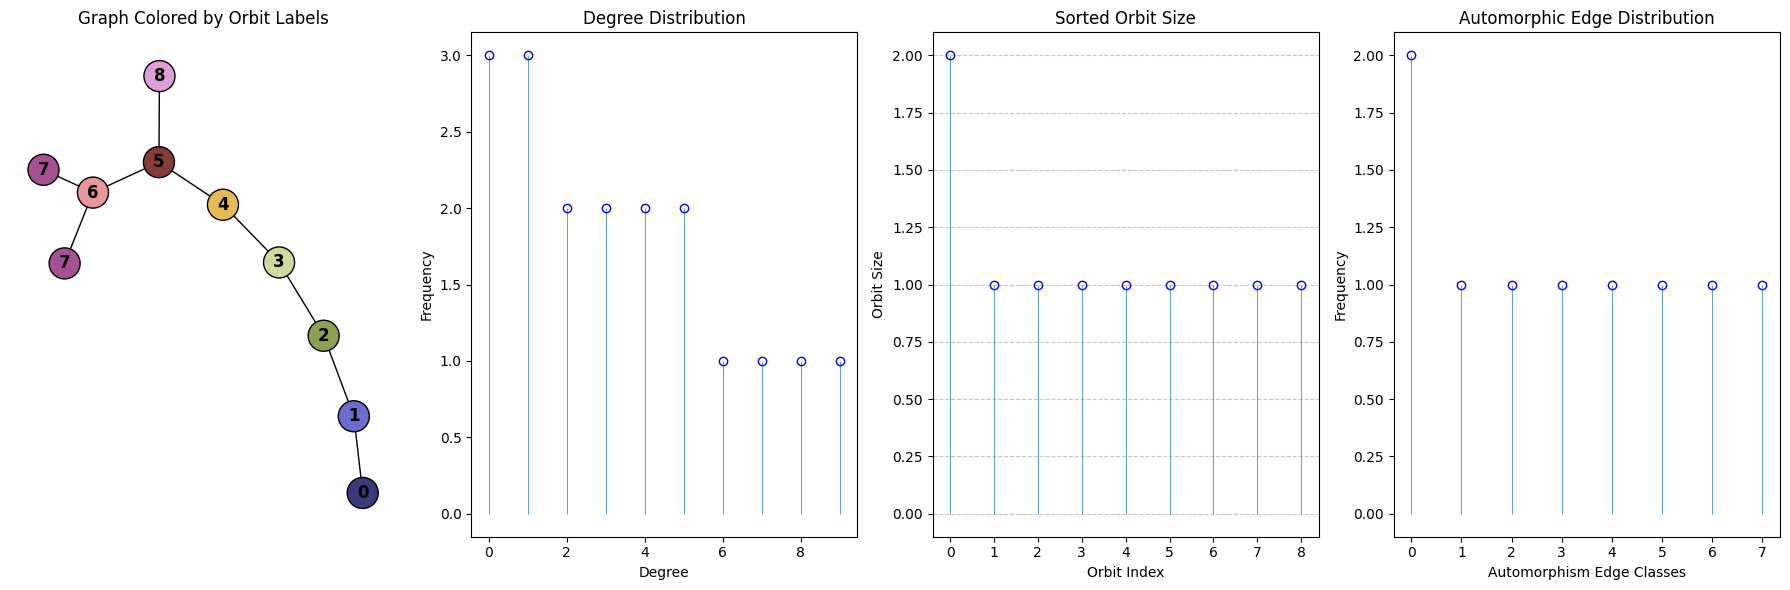

Random type chosen:  GraphType.TREE


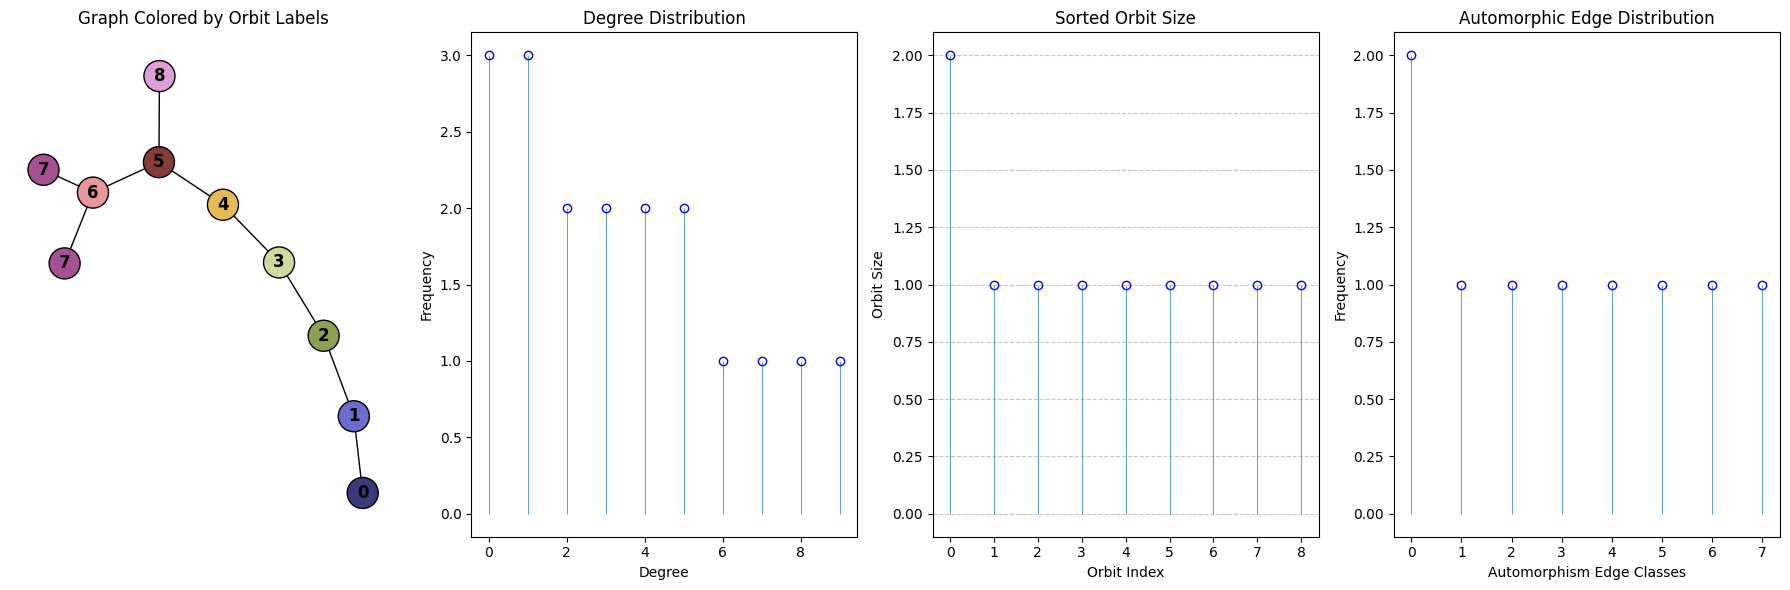

Random type chosen:  GraphType.TREE


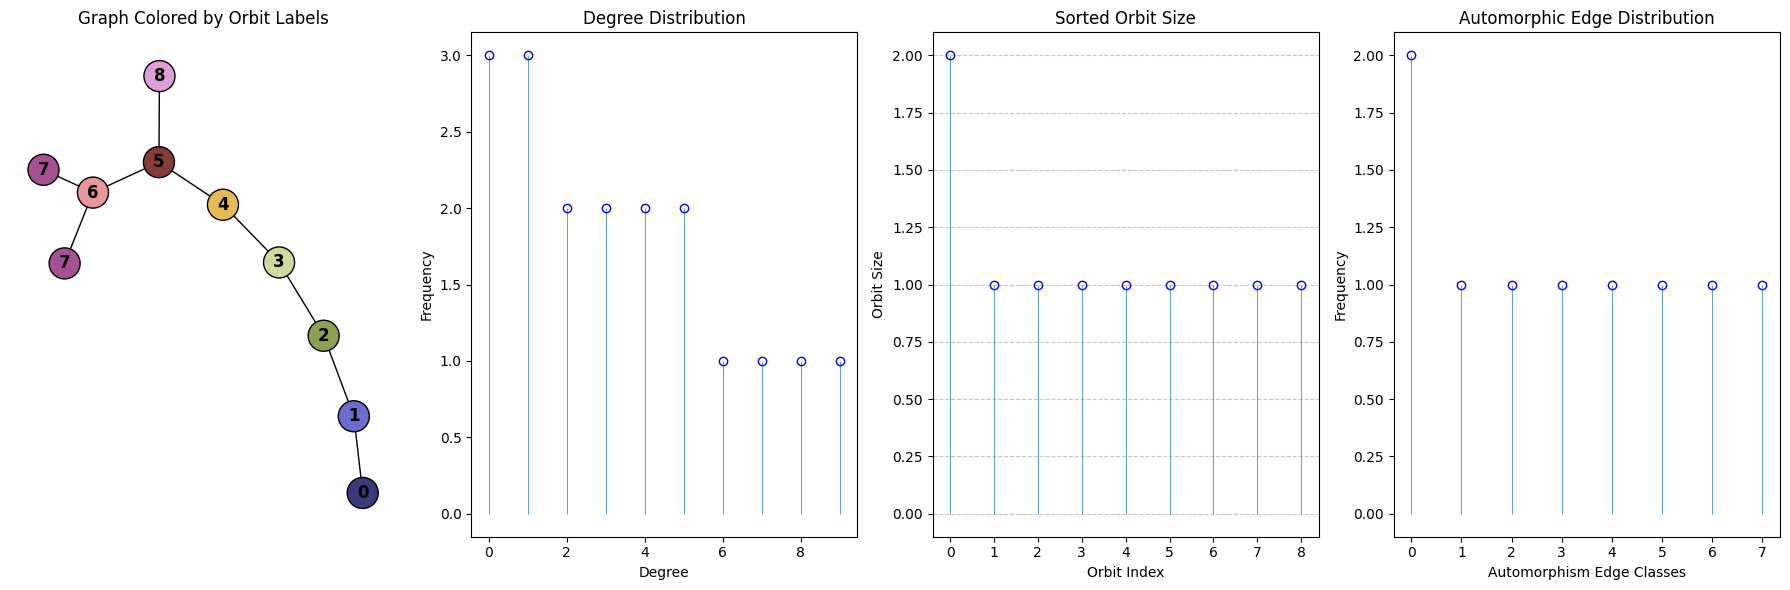

Random type chosen:  GraphType.TREE


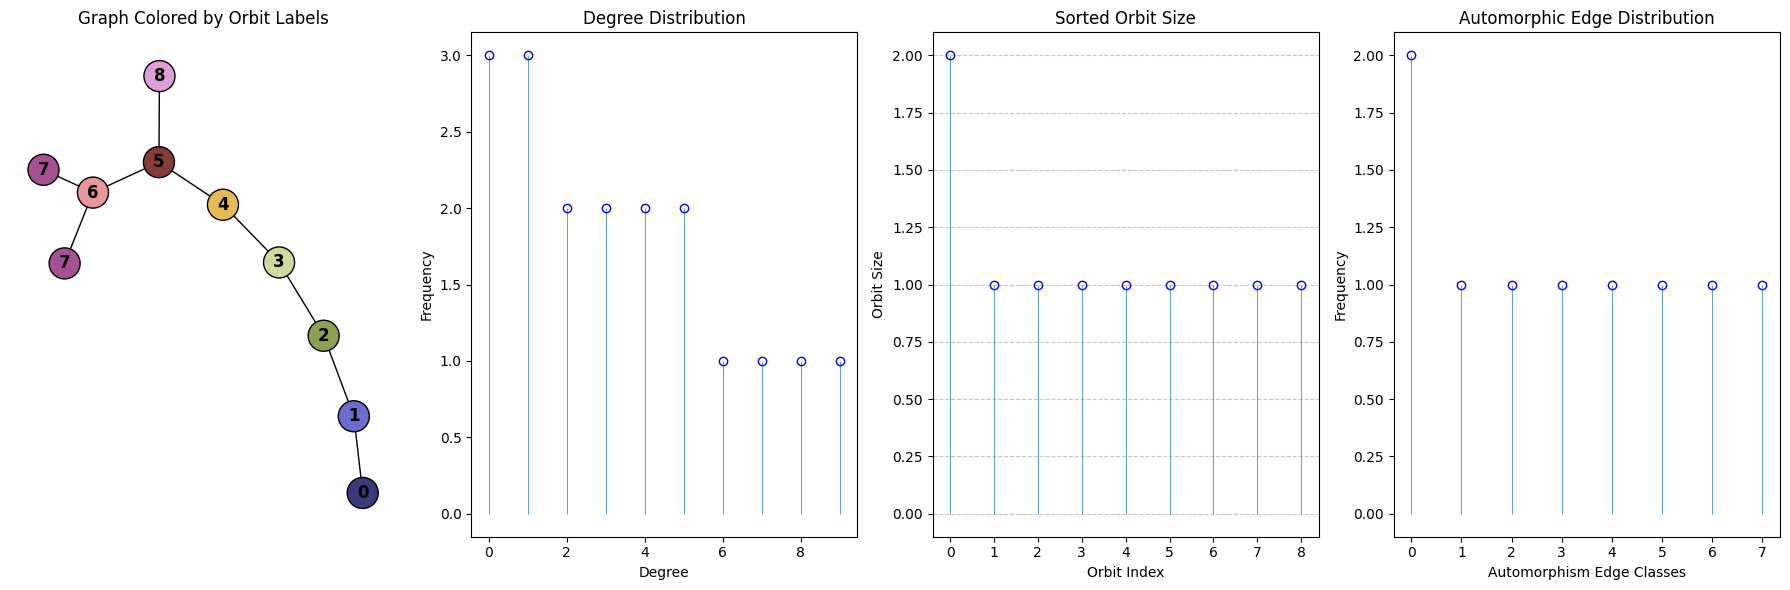

In [19]:
for N in range(4, 40, 10):
    process_graph(10, GraphType.RANDOM)

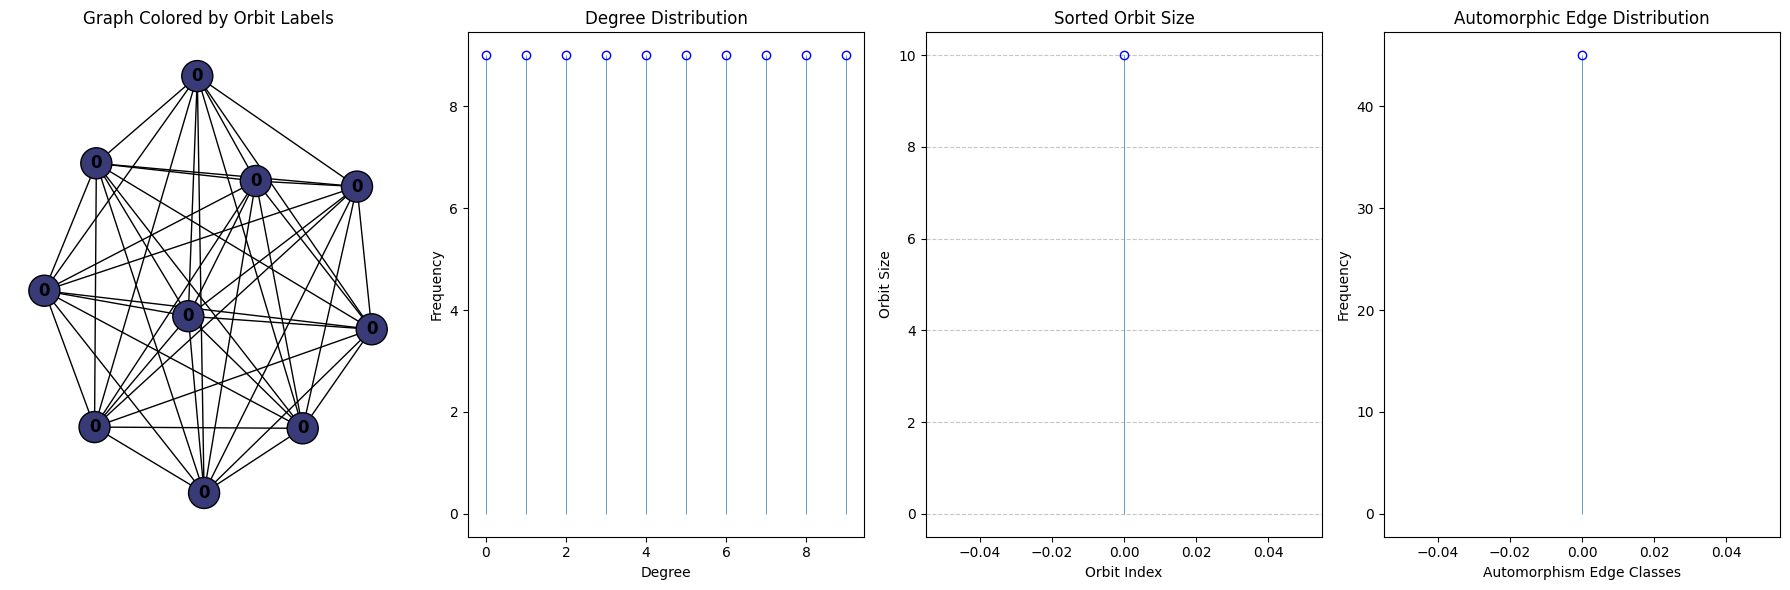

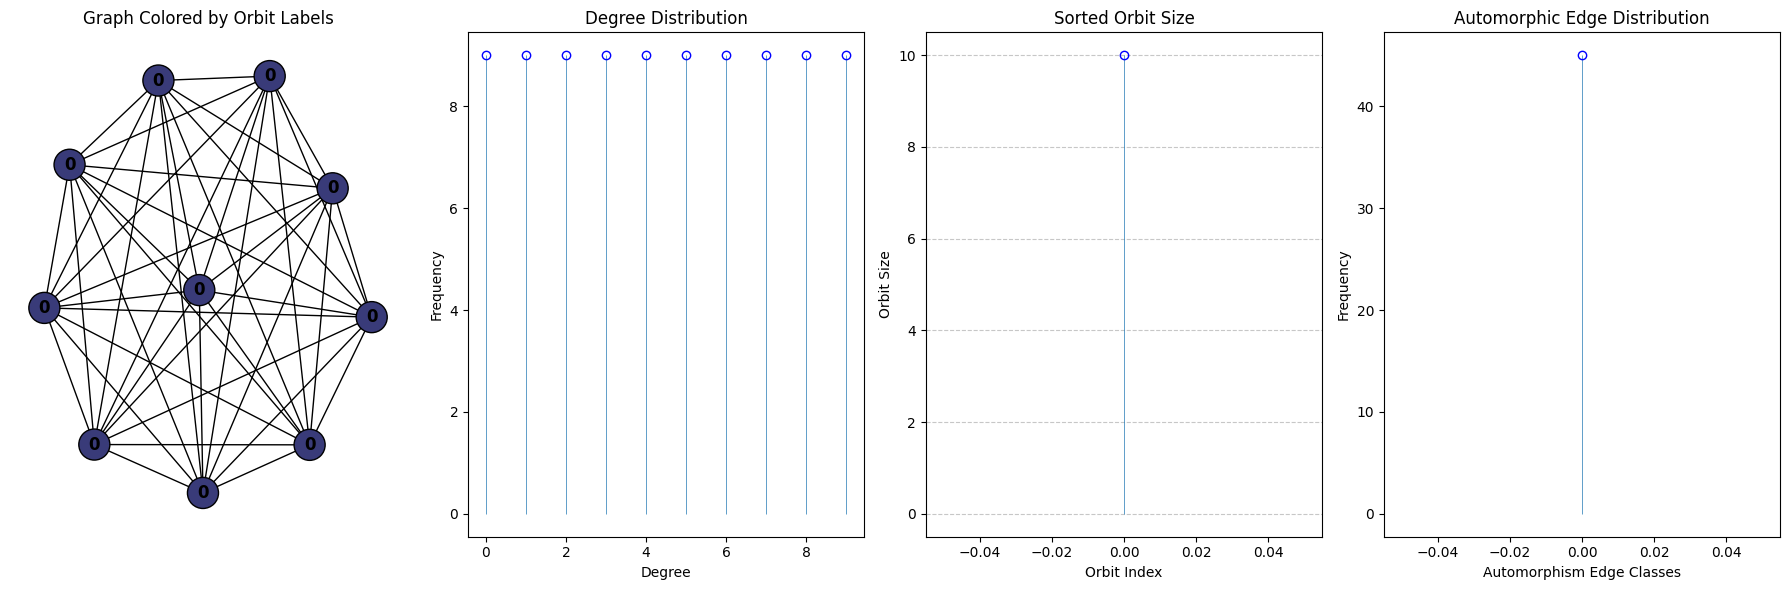

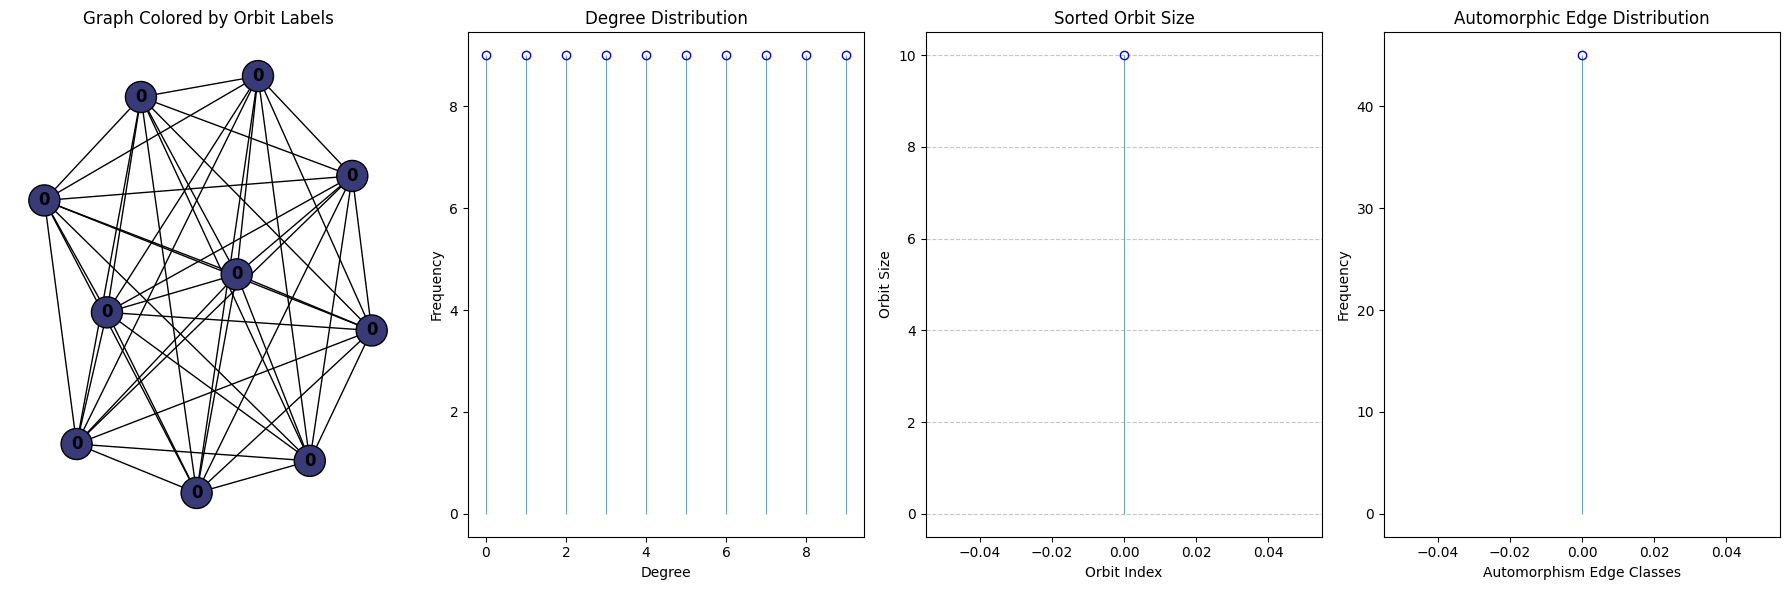

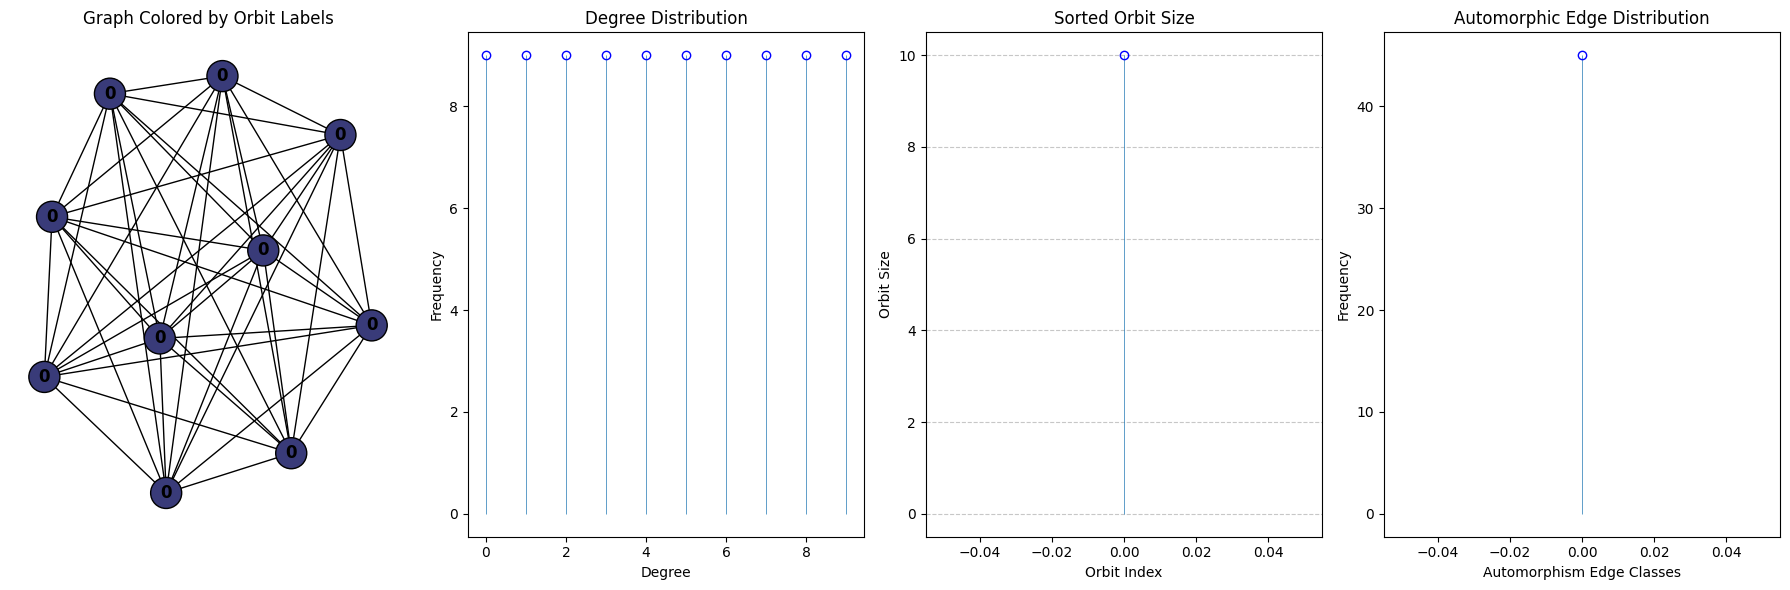

In [20]:
for N in range(4, 40, 10):
    process_graph(10, 'GraphType.COMPLETE', is_grid=True, label="GraphType.COMPLETE")  # Regular tiling case


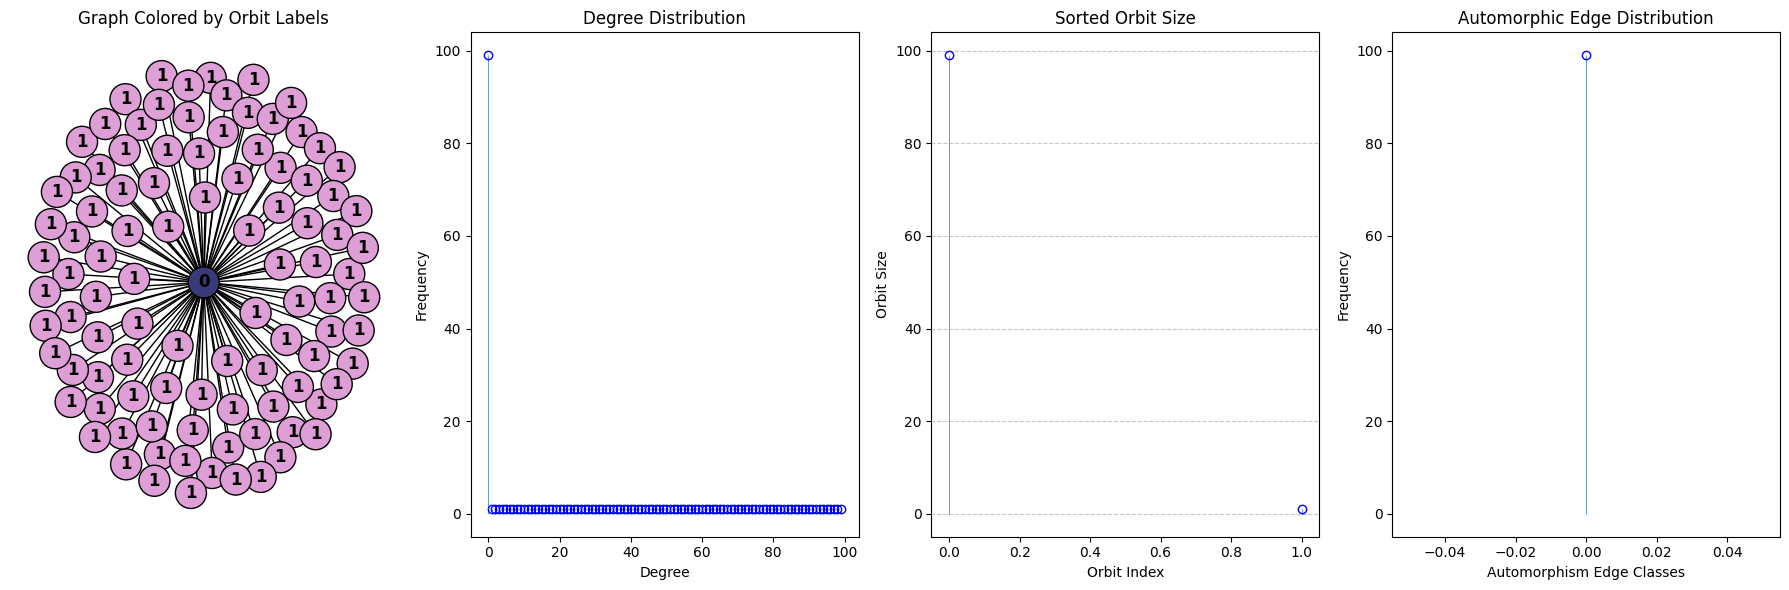

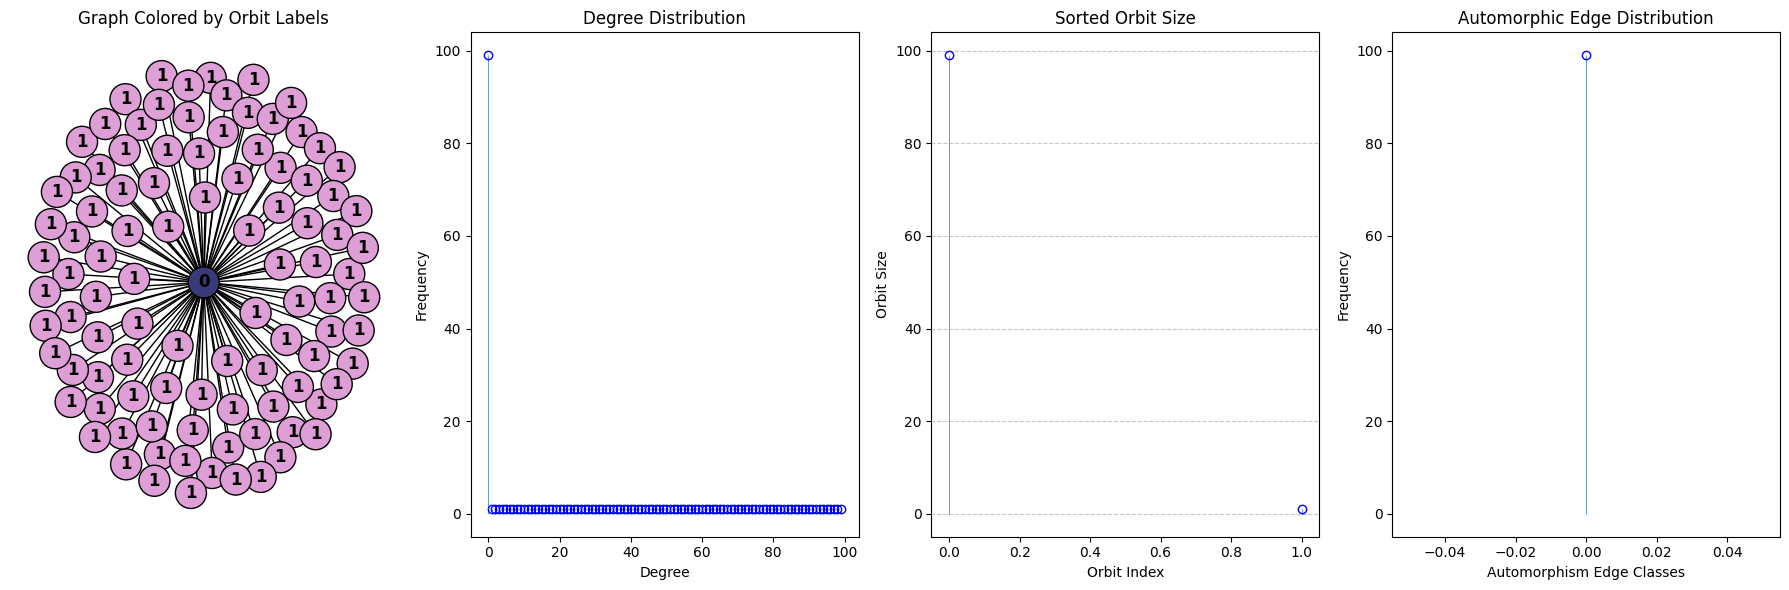

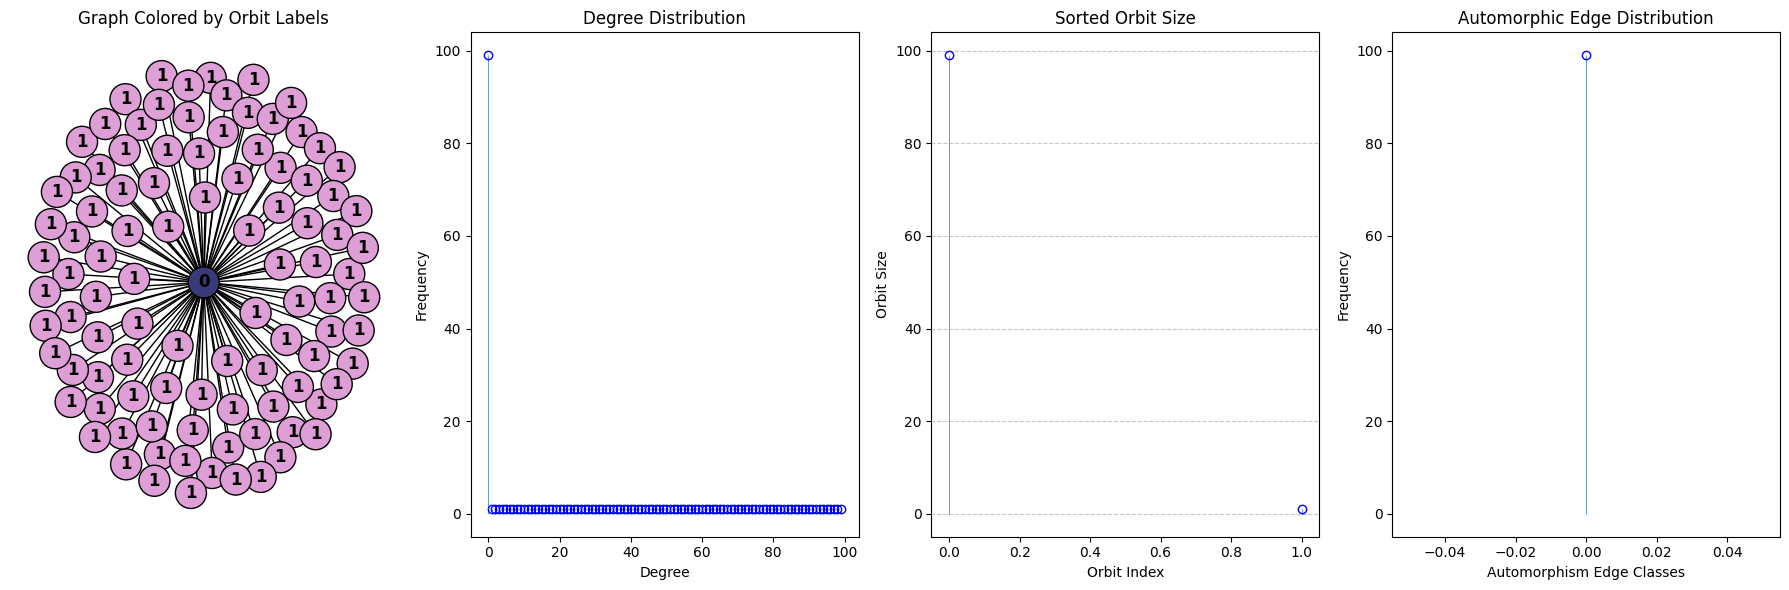

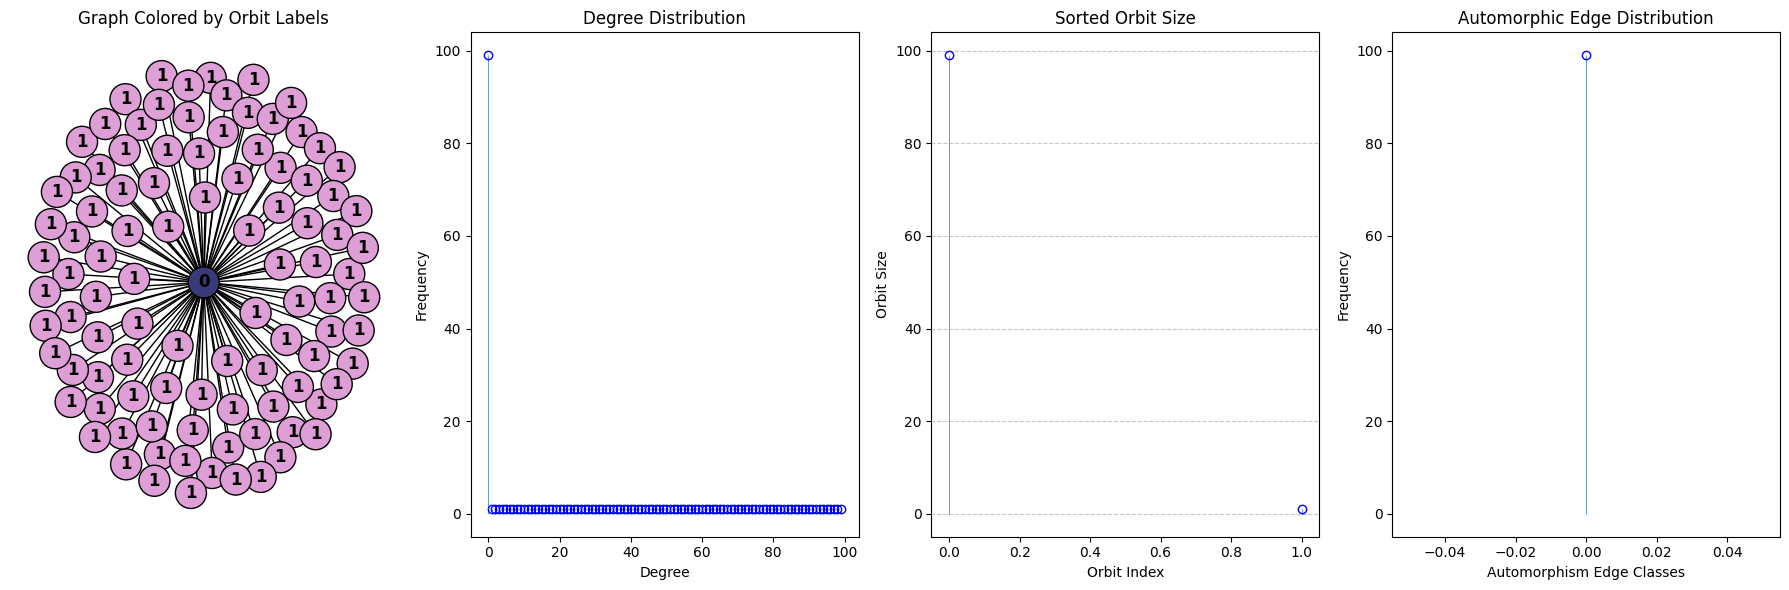

In [21]:
for N in range(4, 40, 10):
    process_graph(100, GraphType.STAR)

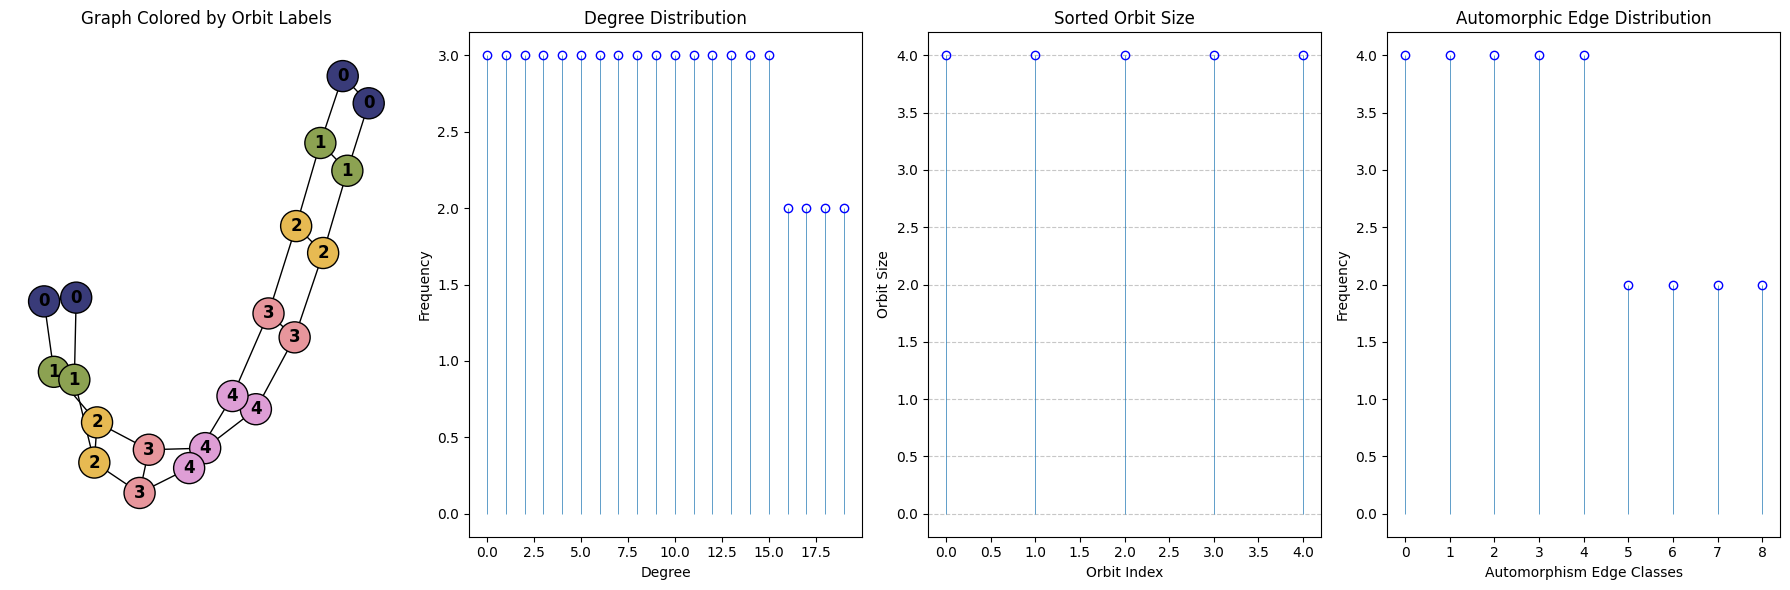

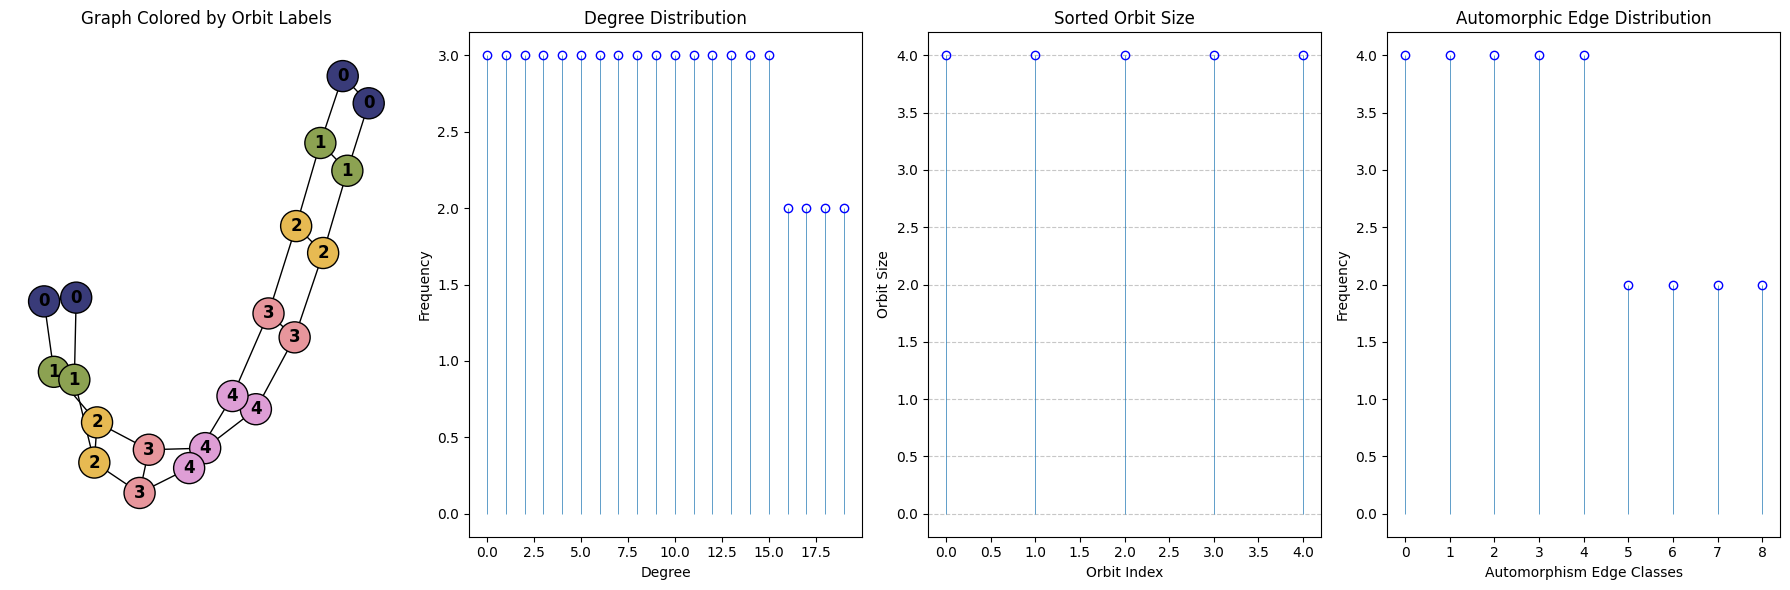

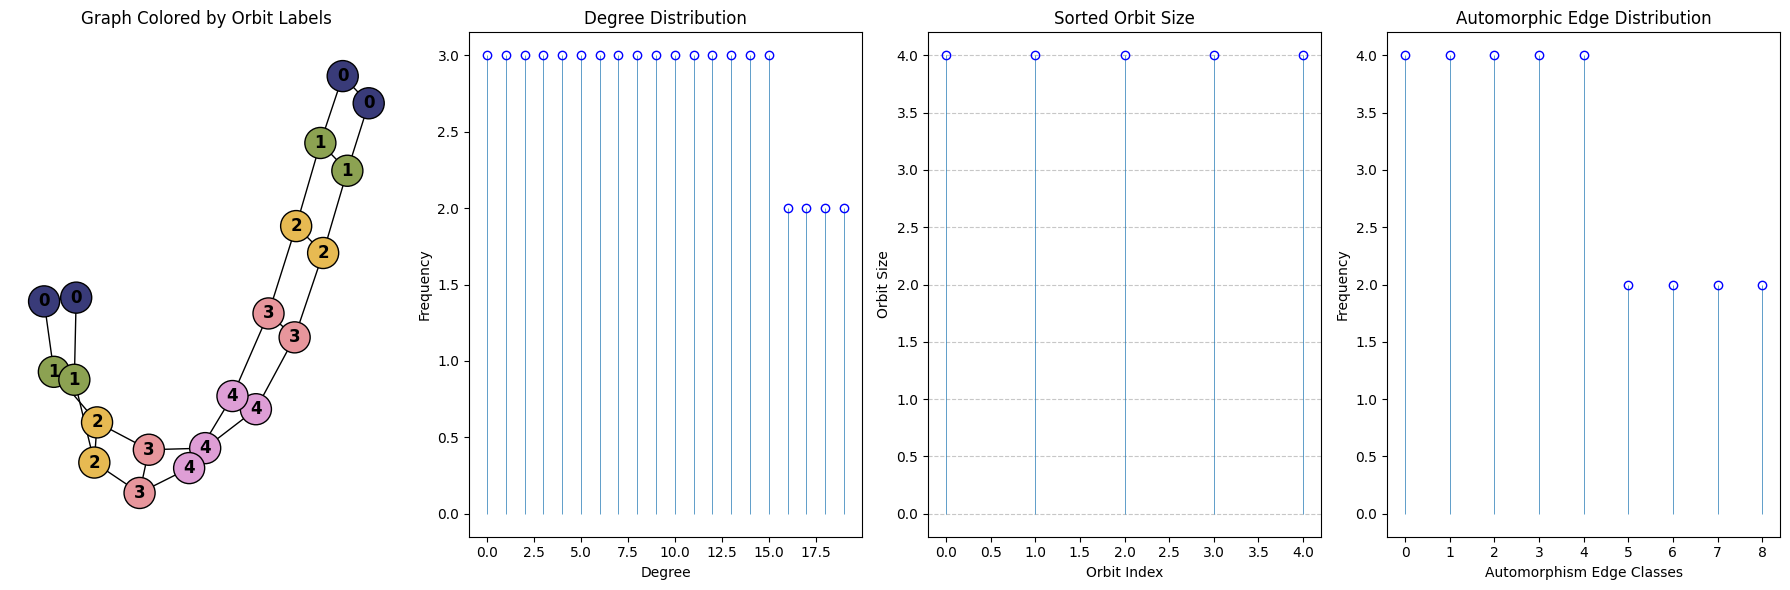

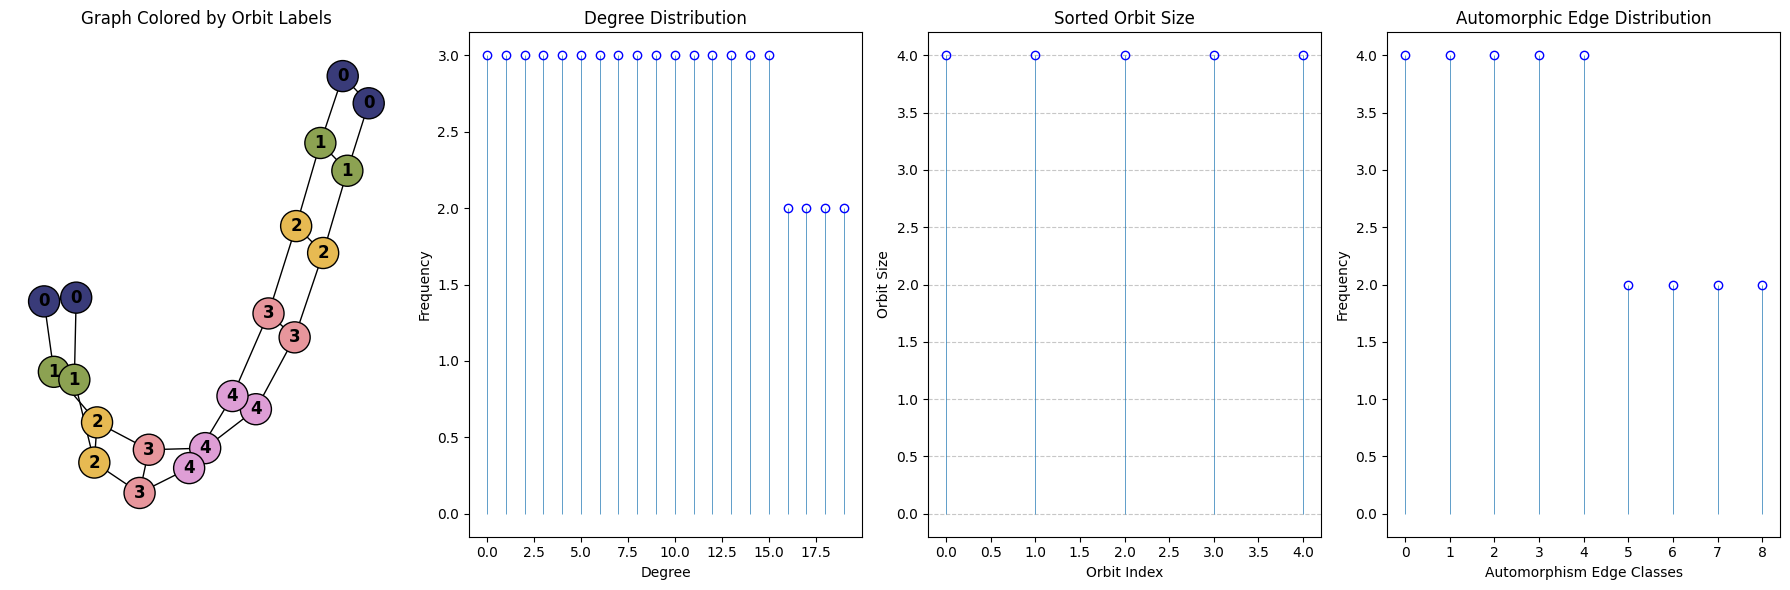

In [22]:
for N in range(4, 40, 10):
    process_graph(20, GraphType.LADDER)
    


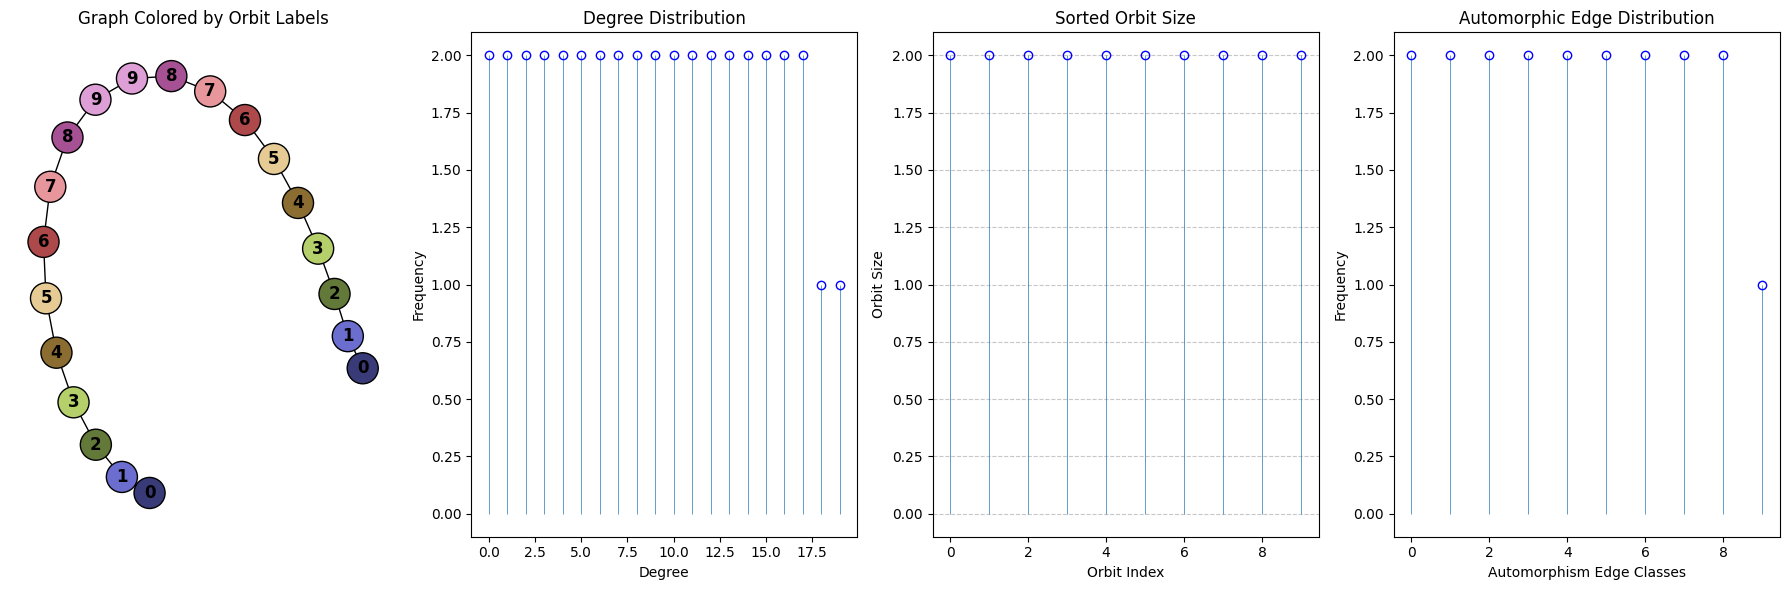

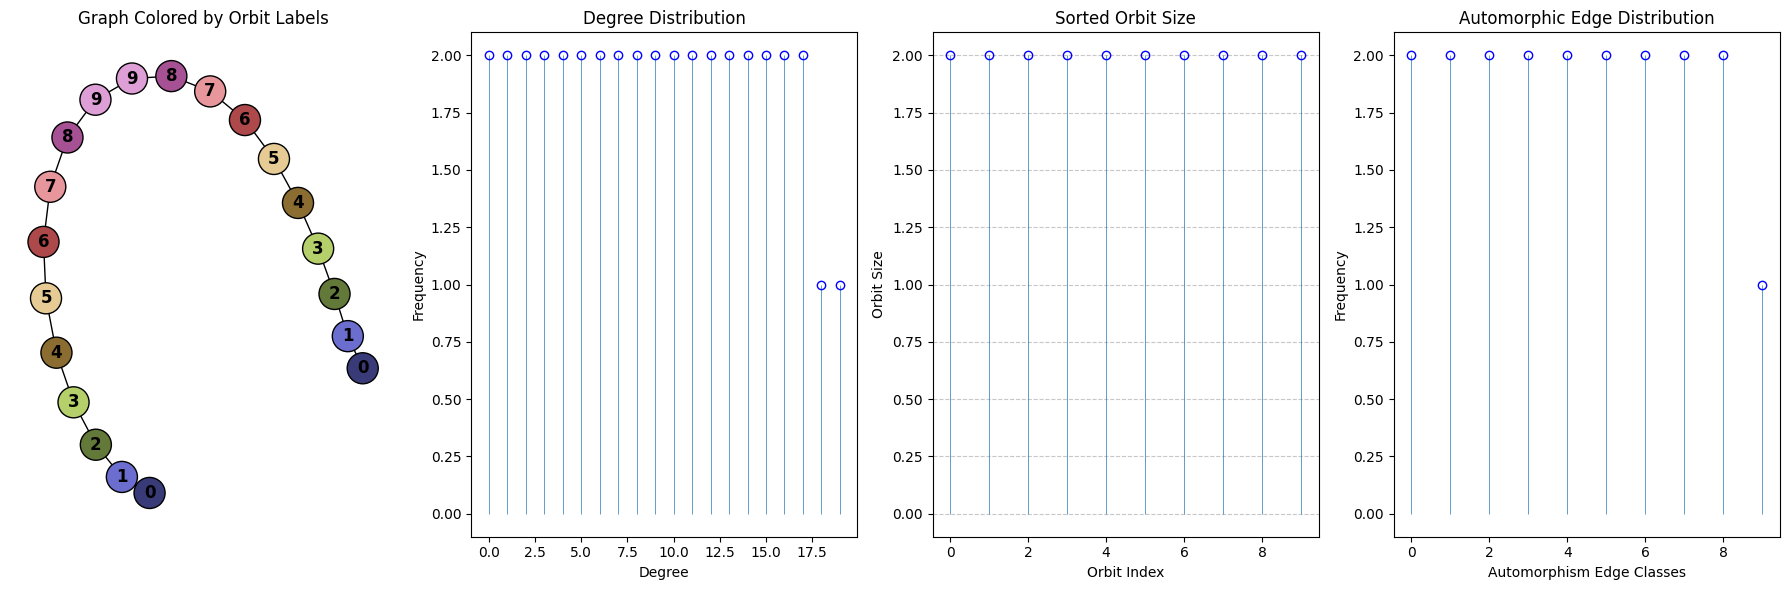

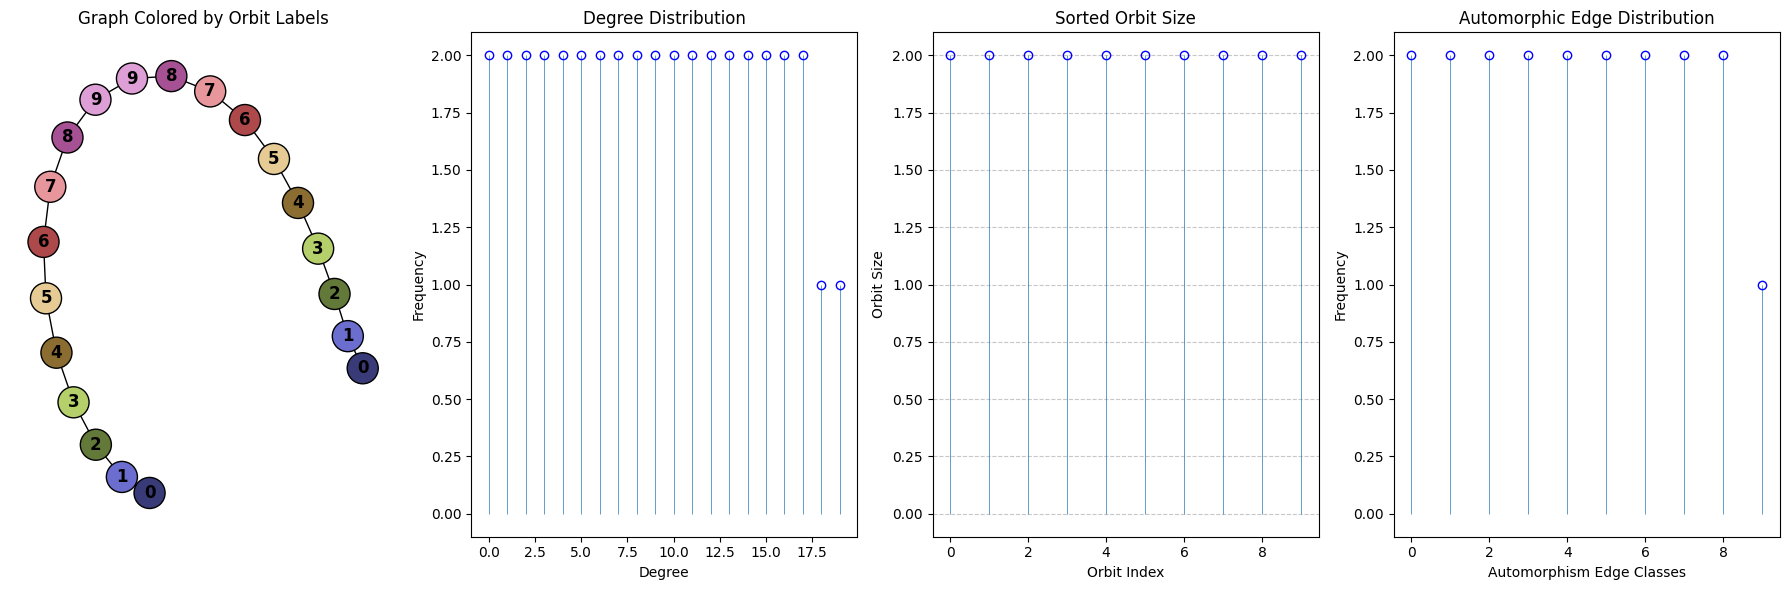

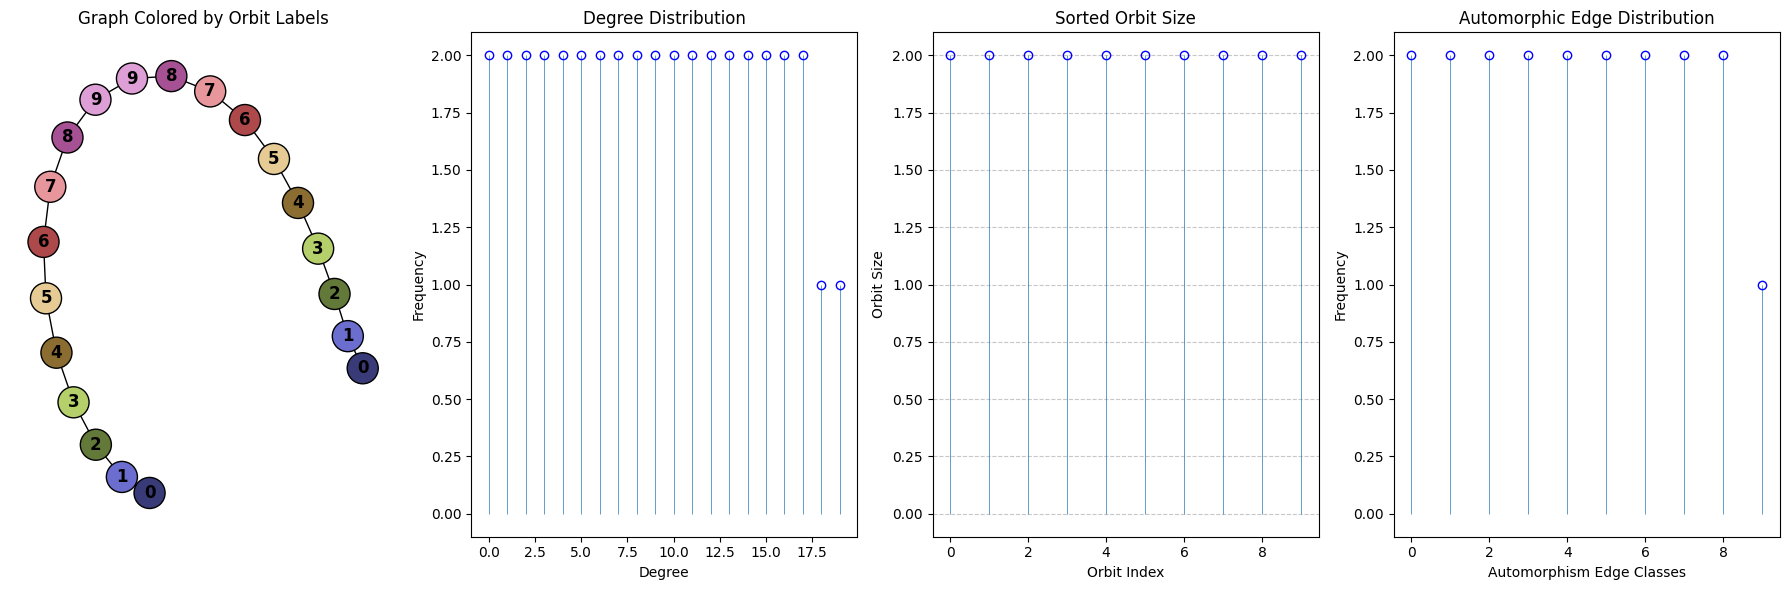

In [23]:
for N in range(4, 40, 10):
    process_graph(20, GraphType.LINE)
    


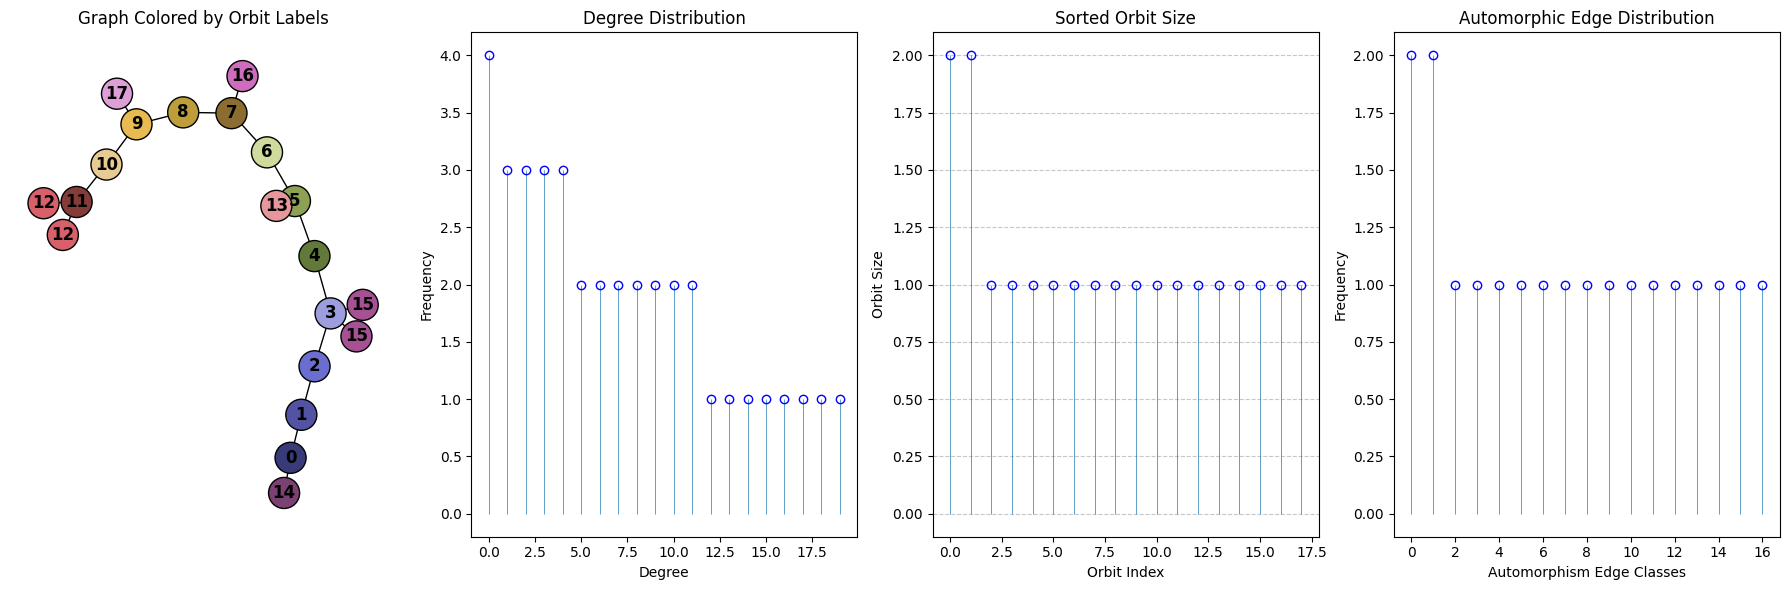

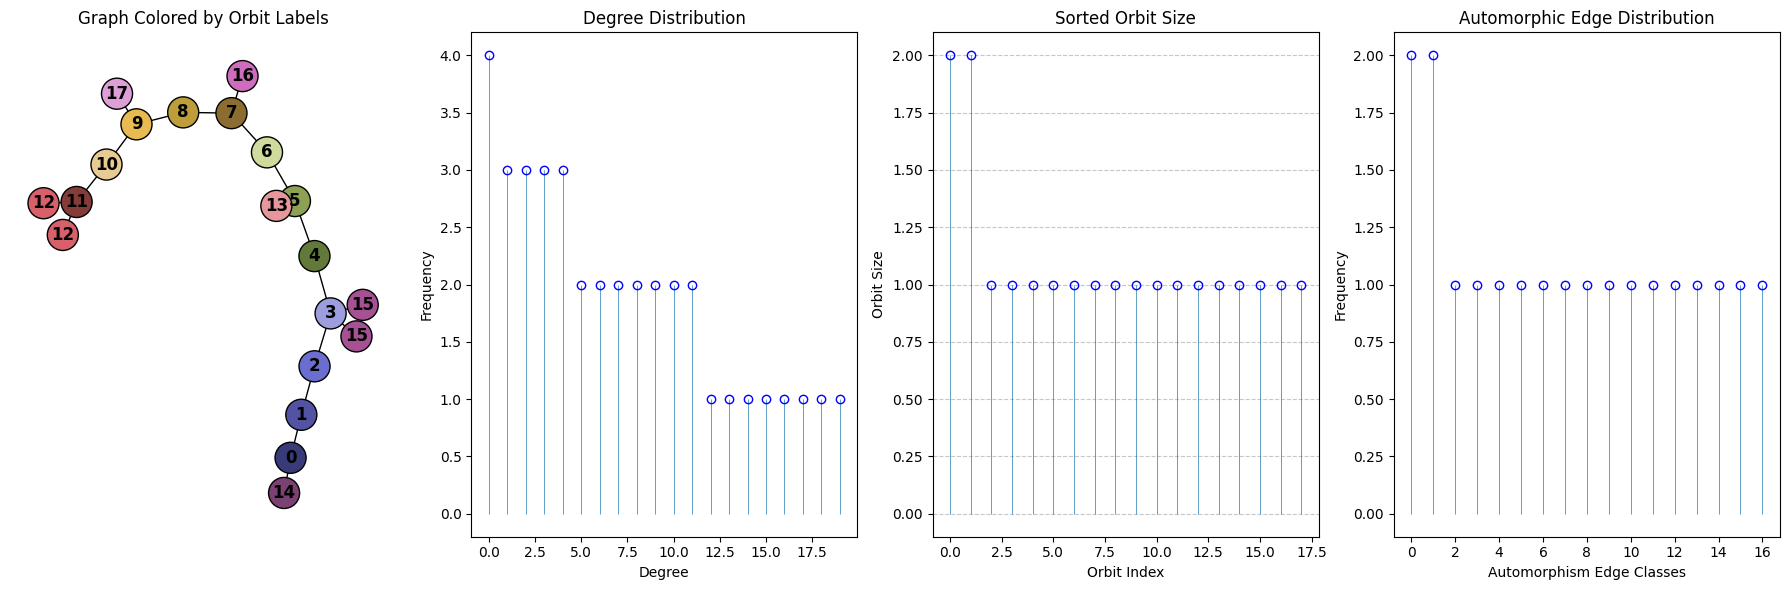

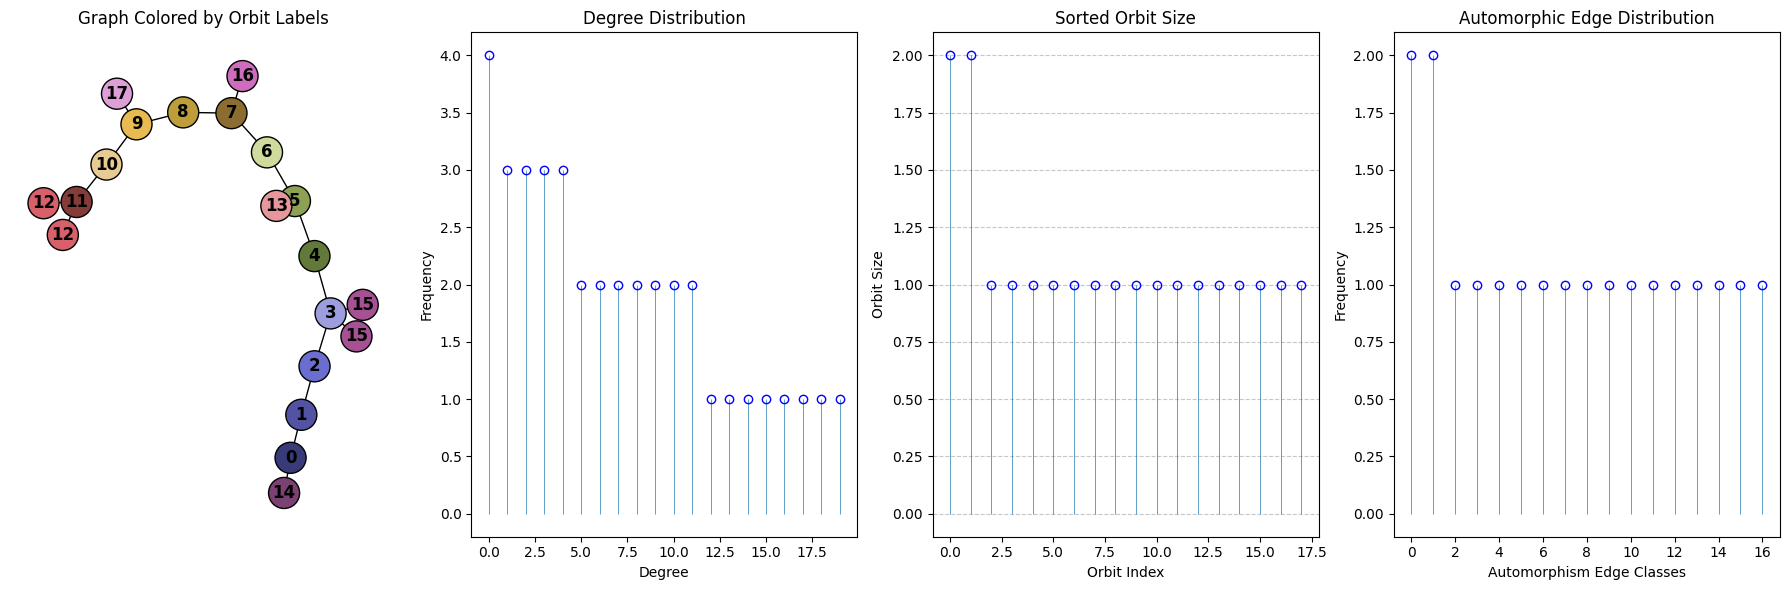

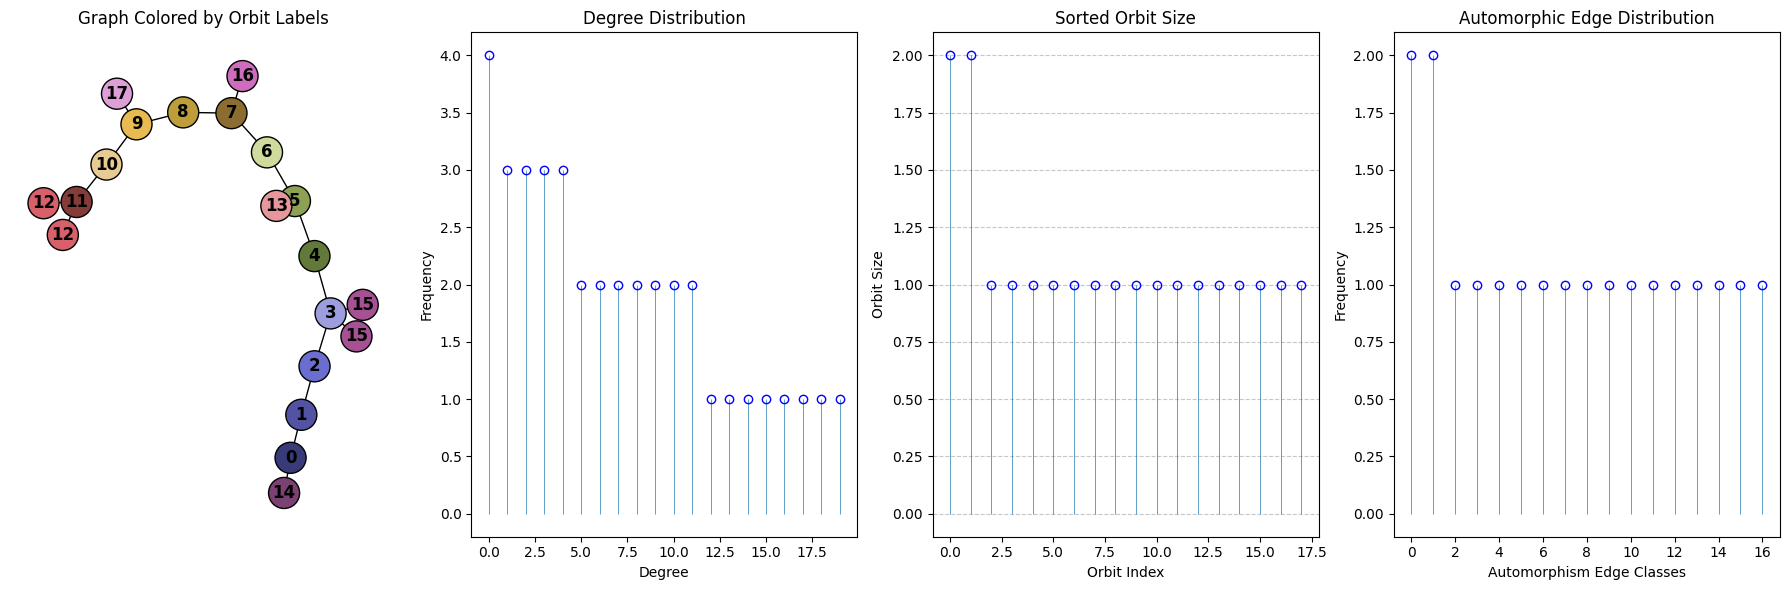

In [24]:
for N in range(4, 40, 10):
    process_graph(20, GraphType.CATERPILLAR)



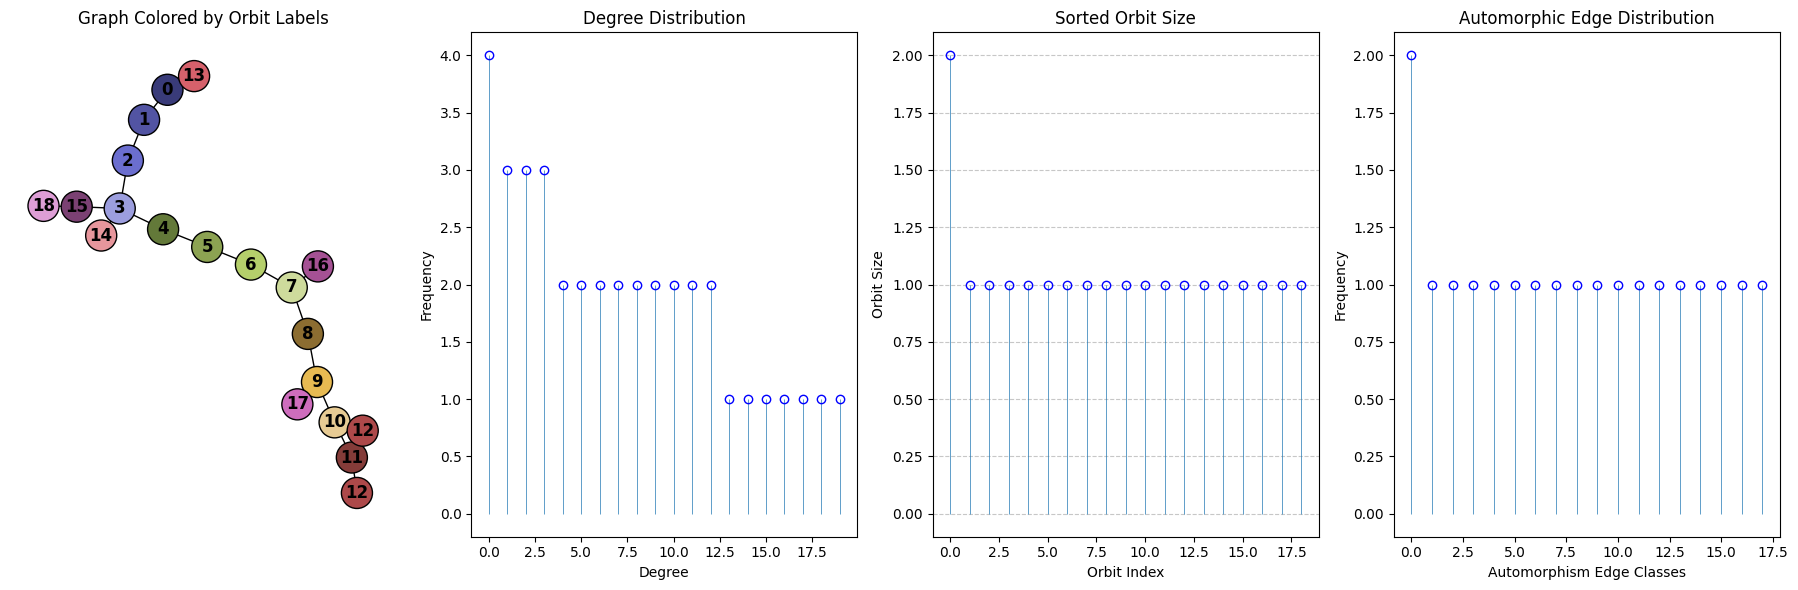

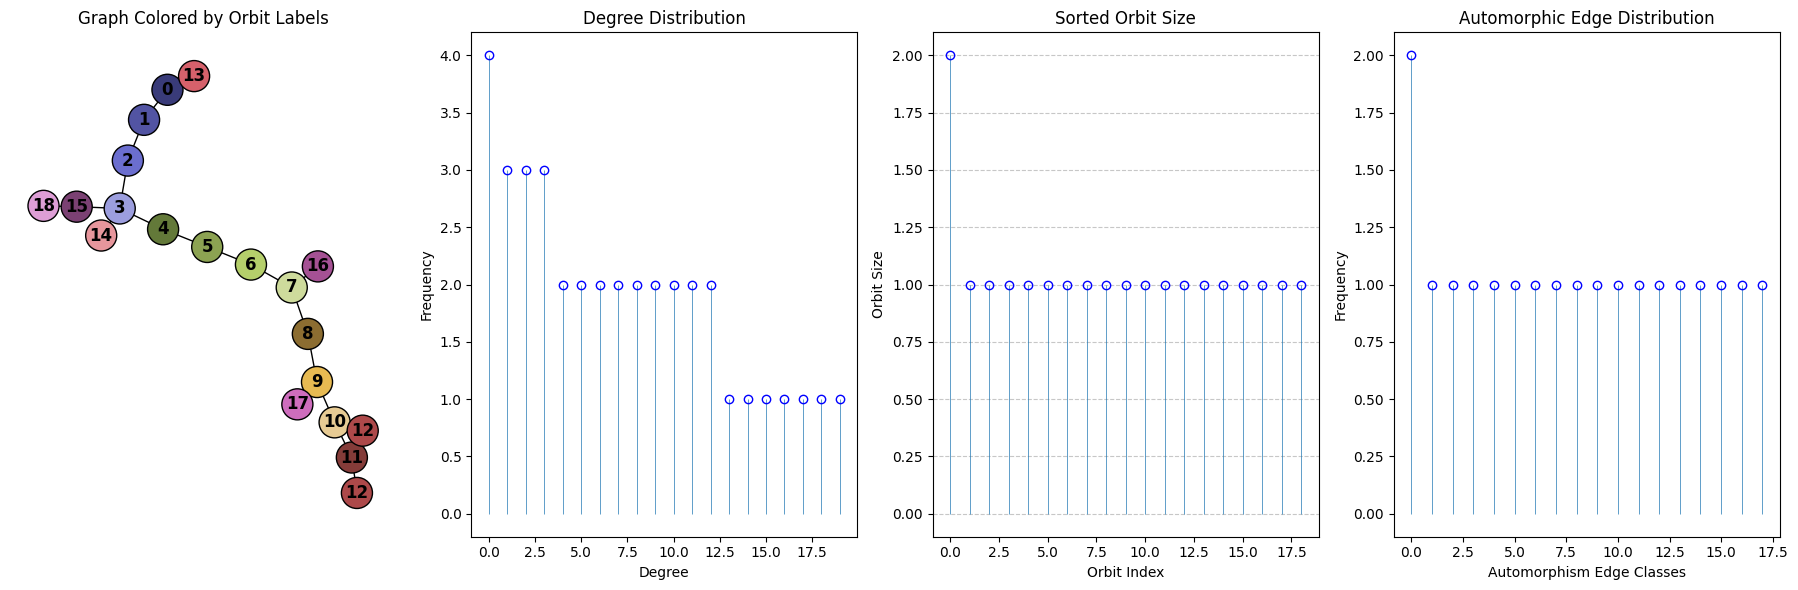

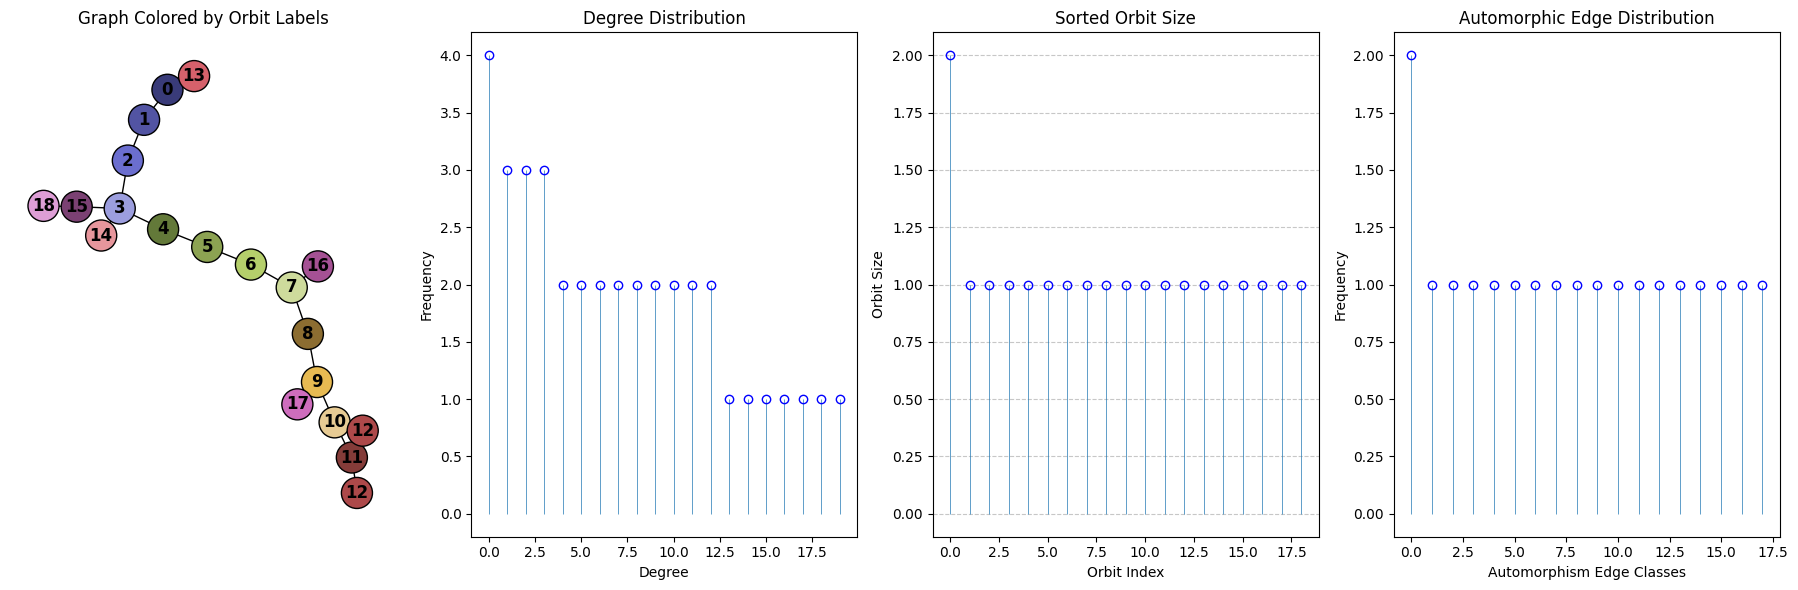

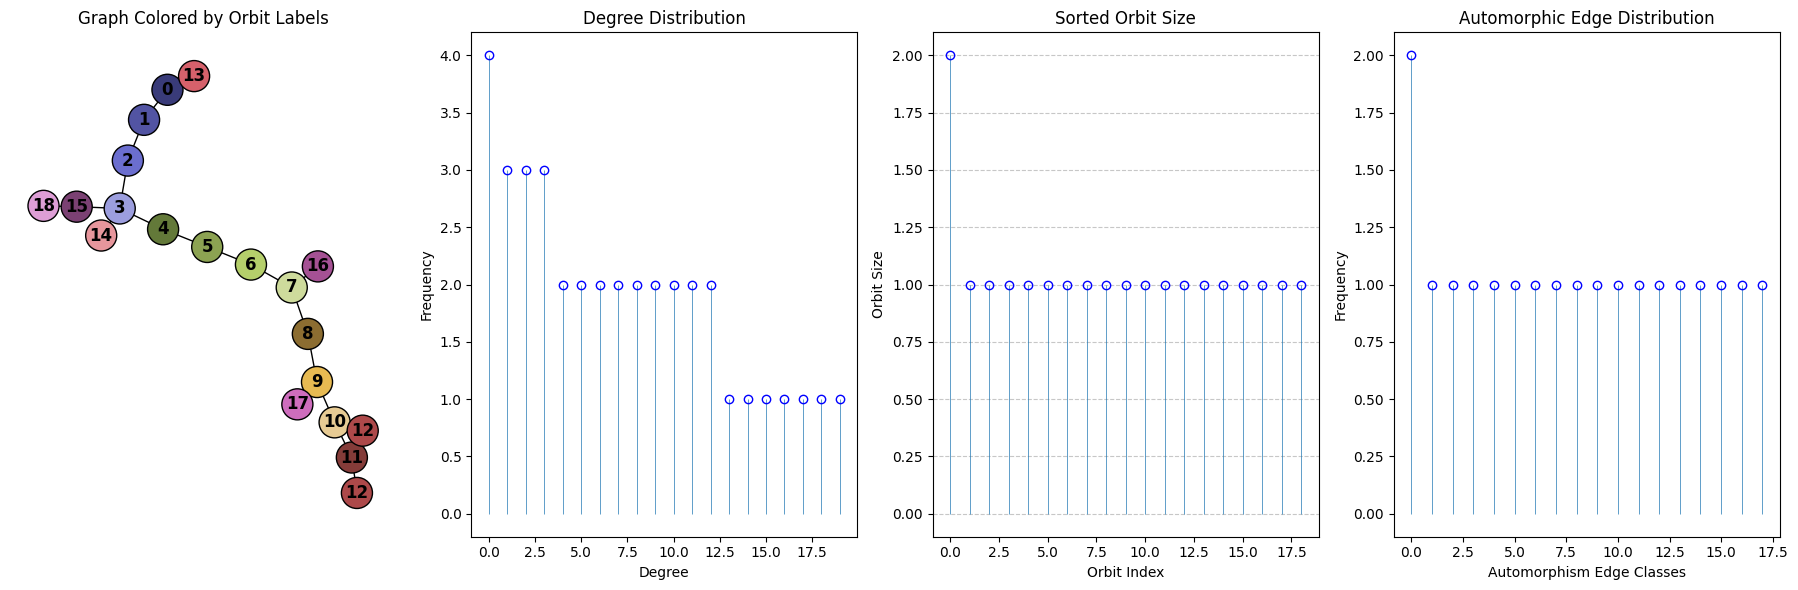

In [25]:
for N in range(4, 40, 10):
    process_graph(20, GraphType.LOBSTER)


